In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import numpy as np
import helper_functions as hf
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
def distance_corr(var_1,var_2,normedweight,power=1):
    """var_1: First variable to decorrelate (eg mass)
    var_2: Second variable to decorrelate (eg classifier output)
    normedweight: Per-example weight. Sum of weights should add up to N (where N is the number of examples)
    power: Exponent used in calculating the distance correlation
    
    va1_1, var_2 and normedweight should all be 1D torch tensors with the same number of entries
    
    Usage: Add to your loss function. total_loss = BCE_loss + lambda * distance_corr
    """
    
    
    xx = var_1.view(-1, 1).repeat(1, len(var_1)).view(len(var_1),len(var_1))
    yy = var_1.repeat(len(var_1),1).view(len(var_1),len(var_1))
    amat = (xx-yy).abs()

    xx = var_2.view(-1, 1).repeat(1, len(var_2)).view(len(var_2),len(var_2))
    yy = var_2.repeat(len(var_2),1).view(len(var_2),len(var_2))
    bmat = (xx-yy).abs()

    amatavg = torch.mean(amat*normedweight,dim=1)
    Amat=amat-amatavg.repeat(len(var_1),1).view(len(var_1),len(var_1))\
        -amatavg.view(-1, 1).repeat(1, len(var_1)).view(len(var_1),len(var_1))\
        +torch.mean(amatavg*normedweight)

    bmatavg = torch.mean(bmat*normedweight,dim=1)
    Bmat=bmat-bmatavg.repeat(len(var_2),1).view(len(var_2),len(var_2))\
        -bmatavg.view(-1, 1).repeat(1, len(var_2)).view(len(var_2),len(var_2))\
        +torch.mean(bmatavg*normedweight)

    ABavg = torch.mean(Amat*Bmat*normedweight,dim=1)
    AAavg = torch.mean(Amat*Amat*normedweight,dim=1)
    BBavg = torch.mean(Bmat*Bmat*normedweight,dim=1)

    if(power==1):
        dCorr=(torch.mean(ABavg*normedweight))/torch.sqrt((torch.mean(AAavg*normedweight)*torch.mean(BBavg*normedweight)))
    elif(power==2):
        dCorr=(torch.mean(ABavg*normedweight))**2/(torch.mean(AAavg*normedweight)*torch.mean(BBavg*normedweight))
    else:
        dCorr=((torch.mean(ABavg*normedweight))/torch.sqrt((torch.mean(AAavg*normedweight)*torch.mean(BBavg*normedweight))))**power
    
    return dCorr
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')
class NeuralNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_hidden_layers):
        super(NeuralNet, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        for i in range(num_hidden_layers):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, output_dim))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_model(model_name, X, Y, mjj, input_dim, hidden_dim, output_dim, num_hidden_layers, num_epochs, batch_size, lr=1e-3,disco_lam=0):
    dataset = TensorDataset(X, Y, mjj)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator(device='cuda'))

    model = NeuralNet(input_dim, hidden_dim, output_dim, num_hidden_layers).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(),lr=lr)

    losses = []
    min_loss = 999999
    for epoch in range(num_epochs):
        for i, data in enumerate(dataloader):
            inputs, labels, mjjs = data
            optimizer.zero_grad()
            outputs = model(inputs)
            if disco_lam==0:
                loss = criterion(outputs, labels)
            else:
                loss = criterion(outputs, labels) + disco_lam*distance_corr(mjjs,outputs,1)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            if loss.item() < min_loss:
                min_loss = loss.item()
                torch.save(model,f"supervised_trainings/{model_name}.pt")

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
    
    model = torch.load(f"supervised_trainings/{model_name}.pt").to(device)
    model.eval()
    plt.plot(np.arange(len(losses)),losses)
    return model

def loadMeans(variables):
    means = []
    stds = []    
    ref_file = "meanStd.h5" # no dEta cut!
    with h5py.File(f"input_h5s/BKG/{ref_file}","r") as f:
        for v in variables:
            means.append(f[v+"_mean"][()])
            stds.append(f[v+"_std"][()])
    means = np.array(means)
    stds = np.array(stds)
    return means, stds

def loadData(sample,variables,nevts,mode="train",dEta_cut=-1,sideband=False):
    if type(sample) == list:
        datas = []
        nev_per = int(nevts/len(sample))
        for samp in sample:
            datas.append(hf.loadData(samp,variables,nMax=nev_per,mode=mode,dEta_cut=dEta_cut,sideband=sideband))
        data = np.concatenate(datas,axis=0)
        np.random.shuffle(data)
    else:
        data = hf.loadData(sample,variables,nMax=nevts,mode=mode,dEta_cut=dEta_cut,sideband=sideband)
    return data

In [3]:
def run_training(sig_sample,mjj_window,alias=None,disco=0,nTrain=100000,nTrain_bkg=1000000,nTest=100000,write=True):
    if type(sig_sample) == list and alias is None:
        print("For multi-signal trainings, need to provide an alias (name for model)!")
        exit()
    
    variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
    variables_mjj = ['mjj']+variables
    
    bkg_train = loadData("BKG",variables_mjj,nTrain_bkg,mode='train',dEta_cut=1.3,sideband=False)
    bkg_test = loadData("BKG",variables_mjj,nTest,mode='test',dEta_cut=1.3,sideband=False)
    bkg_mjj_train, bkg_train = bkg_train[:,0], bkg_train[:,1:]
    bkg_mjj_test, bkg_test = bkg_test[:,0], bkg_test[:,1:]
    
    sig_train = loadData(sig_sample,variables_mjj,nTrain,mode='train',dEta_cut=1.3,sideband=False)
    sig_test = loadData(sig_sample,variables_mjj,nTest,mode='test',dEta_cut=1.3,sideband=False)
    sig_mjj_train, sig_train = sig_train[:,0], sig_train[:,1:]
    sig_mjj_test, sig_test = sig_test[:,0], sig_test[:,1:]
    
    # normalize
    means, stds = loadMeans(variables)
    sig_train = (sig_train-means)/stds
    sig_test = (sig_test-means)/stds
    bkg_train = (bkg_train-means)/stds
    bkg_test = (bkg_test-means)/stds
    
    if mjj_window is not None:
        assert len(mjj_window) == 2
        sig_cut = (sig_mjj_train>mjj_window[0]) & (sig_mjj_train<mjj_window[1])
        bkg_cut = (bkg_mjj_train>mjj_window[0]) & (bkg_mjj_train<mjj_window[1])
        sig_mjj_train = sig_mjj_train[sig_cut]
        sig_train = sig_train[sig_cut]
        bkg_mjj_train = bkg_mjj_train[bkg_cut]
        bkg_train = bkg_train[bkg_cut]
        
        sig_cut = (sig_mjj_test>mjj_window[0]) & (sig_mjj_test<mjj_window[1])
        bkg_cut = (bkg_mjj_test>mjj_window[0]) & (bkg_mjj_test<mjj_window[1])
        sig_mjj_test = sig_mjj_test[sig_cut]
        sig_test = sig_test[sig_cut]
        bkg_mjj_test = bkg_mjj_test[bkg_cut]
        bkg_test = bkg_test[bkg_cut]
    
    print("Signal training: ",sig_train.shape[0])
    print("Signal testing: ",sig_test.shape[0])
    print("Bkg training: ",bkg_train.shape[0])
    print("Bkg testing: ",bkg_test.shape[0])

    train = np.concatenate((sig_train,bkg_train),axis=0)
    train_mjj = np.concatenate((sig_mjj_train,bkg_mjj_train),axis=0)
    train_label = np.concatenate((np.ones((sig_train.shape[0],1)),np.zeros((bkg_train.shape[0],1))),axis=0)
    p1 = np.random.permutation(train.shape[0])
    train = train[p1]
    train_mjj = train_mjj[p1]
    train_label = train_label[p1]

    test = np.concatenate((sig_test,bkg_test),axis=0)
    test_mjj = np.concatenate((sig_mjj_test,bkg_mjj_test),axis=0)
    test_label = np.concatenate((np.ones((sig_test.shape[0],1)),np.zeros((bkg_test.shape[0],1))),axis=0)
    p1 = np.random.permutation(test.shape[0])
    test = test[p1]
    test_label = test_label[p1]
    test_mjj = test_mjj[p1]
    
    print("Train: ",train.shape[0])
    print("Test: ",test.shape[0])
    
    # train the model
    name_core = sig_sample if alias is None else alias
    if mjj_window is not None:
        outName = f"NNScore_{name_core}_mjj{int(mjj_window[0])}-{int(mjj_window[1])}"
        model_name = f"{name_core}_mjj{int(mjj_window[0])}-{int(mjj_window[1])}"
    else:
        outName = f"NNScore_{name_core}_mjjAll"
        model_name = f"{name_core}_mjjAll"
    disco_lam = 0
    if disco != 0:
        outName += "_disco"
        model_name += "_disco"
        disco_lam = disco
    model = train_model(model_name,
                        torch.tensor(train,device=device,dtype=torch.float32),
                        torch.tensor(train_label,device=device,dtype=torch.float32),
                        torch.tensor(train_mjj,device=device,dtype=torch.float32),
                        input_dim=len(variables),hidden_dim=100,output_dim=1,num_hidden_layers=4,
                        num_epochs=50,batch_size=10000,disco_lam=disco_lam)
    
    # Make various plots
    #plot auc
    with torch.no_grad():
        preds = model(torch.tensor(test,dtype=torch.float32,device=device)).detach().cpu().numpy()
    auc = roc_auc_score(test_label,preds)
    fpr,tpr,thresh = roc_curve(test_label,preds)
    plt.figure(figsize=(6,6))
    plt.plot(tpr,1-fpr)
    plt.title(f"AUC = {auc:.4f}")

    cuts = np.linspace(0.5,1,100)
    bkg_yield = []
    val = []
    mjj200_bkg = []
    mjj200_sig = []
    for c in cuts:
        cut = preds > c
        passing = test_label[cut]
        passing_mjj = test_mjj[cut[:,0]]
        ns = np.count_nonzero(passing==1)
        nb = np.count_nonzero(passing==0)
        bkg_yield.append(nb)
        if nb > 0:
            val.append(ns/np.sqrt(nb))
        else:
            val.append(np.inf if ns > 0 else 0)
        if nb > 500:
            mjj200_bkg = passing_mjj[passing==0]
            mjj200_sig = passing_mjj[passing==1]

    bkg_yield = np.array(bkg_yield)
    val = np.array(val)
    srt = np.argsort(bkg_yield)
    bkg_yield = bkg_yield[srt]
    val = val[srt]

    plt.figure(figsize=(8,6))
    plt.plot(bkg_yield,val)
    plt.xlabel('Background Yield')
    plt.ylabel(r"$S/\sqrt{B}$")
    if mjj_window is not None:
        plt.title(r"{0}, $m_{{jj}} \in [{1},{2}]$".format(name_core,mjj_window[0],mjj_window[1]))
    else:
        plt.title(r"{0}, All $m_{{jj}}$".format(name_core))
    #plot masses
    plt.figure(figsize=(8,6))
    #bins=np.linspace(1800,4000,20)
    h1,bins,_ = plt.hist(mjj200_bkg,bins=40,histtype='step',label="BKG",density=True)
    h2 = plt.hist(mjj200_sig,bins=bins,histtype='step',label=name_core,density=True)
    h3 = plt.hist(test_mjj[test_label[:,0]==0],histtype='step',bins=bins,label='full bkg test set',density=True)
    plt.title(r"$m_{jj}$ distributions with 500 bkg events accepted")
    plt.yscale('log')
    plt.legend(loc='upper right')
    
    plt.figure(figsize=(6,6))
    plt.scatter(test_mjj[test_label[:,0]==0],preds[test_label[:,0]==0],s=2,label="BKG")
    plt.scatter(test_mjj[test_label[:,0]==1],preds[test_label[:,0]==1],s=2,label=name_core)

    #plt.figure(figsize=(8,6))
    #h1,bins,_ = plt.hist(train_mjj[train_label[:,0]==0],bins=20,histtype='step',label="BKG",density=True)
    #h2 = plt.hist(train_mjj[train_label[:,0]==1],bins=bins,histtype='step',label=sig_sample,density=True)
    #plt.legend(loc='upper right')
    
    # correlation w/ mjj
    mjj_corr = np.corrcoef(preds[:,0],test_mjj,rowvar=False)
    print("Mjj_correlation:")
    print(mjj_corr)
    
    if write:
        # evaluate NN on other data and write results
        variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
                     'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
        bkg = loadData("BKG",variables_mjj,-1,mode='all',dEta_cut=1.3,sideband=False)
        bkg,bkg_mjj = bkg[:,1:],bkg[:,0]
        data = loadData("DATA",variables_mjj,-1,mode='all',dEta_cut=-1,sideband=True)
        data,data_mjj = data[:,1:],data[:,0]
        
        means, stds = loadMeans(variables)
        bkg = (bkg-means)/stds
        data = (data-means)/stds
        
        if type(sig_sample) == list:
            sigs = []
            sig_mjjs = []
            for samp in sig_sample:
                inp_sig = loadData(samp,variables_mjj,-1,mode='all',dEta_cut=1.3,sideband=False)
                inp_sig, inp_mjj = inp_sig[:,1:], inp_sig[:,0]
                sigs.append((inp_sig-means)/stds)
                sig_mjjs.append(inp_mjj)
        else:
            sig = loadData(sig_sample,variables_mjj,-1,mode='all',dEta_cut=1.3,sideband=False)
            sig,sig_mjj = sig[:,1:],sig[:,0]
            sig = (sig-means)/stds

        with torch.no_grad():
            if type(sig_sample) == list:
                sig_preds = [model(torch.tensor(samp_data,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0] for samp_data in sigs]
            else:
                sig_preds = model(torch.tensor(sig,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0]

            bkg_chunks = np.array_split(bkg,1+bkg.shape[0]//100000)
            bkg_preds = []
            for c in bkg_chunks:
                bkg_preds.append(model(torch.tensor(c,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0])
            bkg_preds = np.concatenate(bkg_preds,axis=0)

            data_chunks = np.array_split(data,1+data.shape[0]//100000)
            data_preds = []
            for c in data_chunks:
                data_preds.append(model(torch.tensor(c,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0])
            data_preds = np.concatenate(data_preds,axis=0)

        dirs = ['lossEvals','lossEvals_linearDecorr','lossEvals_linearDecorr_boxCox',
               'lossEvals_pcaDecorr','lossEvals_pcaDecorr_boxCox',
               'lossEvals_noDecorr','lossEvals_noDecorr_boxCox']
        for d in dirs:
            if type(sig_sample) == list:
                for i,s in enumerate(sig_sample):
                    fs = d+f"/{s}.h5"
                    with h5py.File(fs,"r+") as fout:
                        if not np.all(fout['mjj'][()]==sig_mjjs[i]):
                            print(f"Bad {fs}, mjjs don't match!")
                        else:
                            if outName in fout.keys():
                                del fout[outName]
                            fout.create_dataset(outName,data=sig_preds[i])
            else: 
                fs = d+f"/{sig_sample}.h5"
                with h5py.File(fs,"r+") as fout:
                    if not np.all(fout['mjj'][()]==sig_mjj):
                        print(f"Bad {fs}, mjjs don't match!")
                    else:
                        if outName in fout.keys():
                            del fout[outName]
                        fout.create_dataset(outName,data=sig_preds)
            fb = d+"/BKG.h5"
            fd = d+"/DATA_SB.h5"
            with h5py.File(fb,"r+") as fout:
                if not np.all(fout['mjj'][()]==bkg_mjj):
                    print(f"Bad {fb}, mjjs don't match!")
                else:
                    if outName in fout.keys():
                        del fout[outName]
                    fout.create_dataset(outName,data=bkg_preds)
            with h5py.File(fd,"r+") as fout:
                if not np.all(fout['mjj'][()]==data_mjj):
                    print(f"Bad {fd}, mjjs don't match!")
                else:
                    if outName in fout.keys():
                        del fout[outName]
                    fout.create_dataset(outName,data=data_preds)

# Fully supervised trainings

100%|██████████| 1/1 [00:00<00:00, 31.05it/s]


Signal training:  74707
Signal testing:  8301
Bkg training:  500000
Bkg testing:  100000
Train:  574707
Test:  108301
Epoch 10, Loss: 0.0605
Epoch 20, Loss: 0.0560
Epoch 30, Loss: 0.0537
Epoch 40, Loss: 0.0539
Epoch 50, Loss: 0.0590
Mjj_correlation:
[[1.         0.85072803]
 [0.85072803 1.        ]]


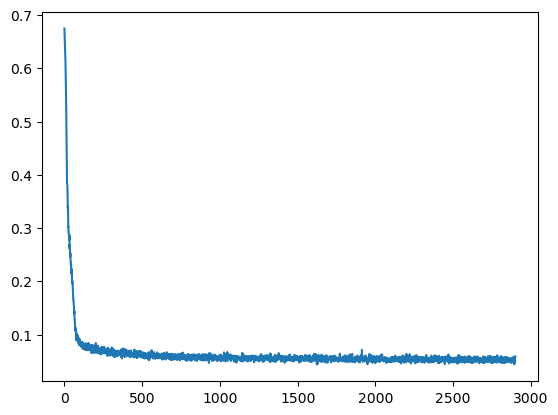

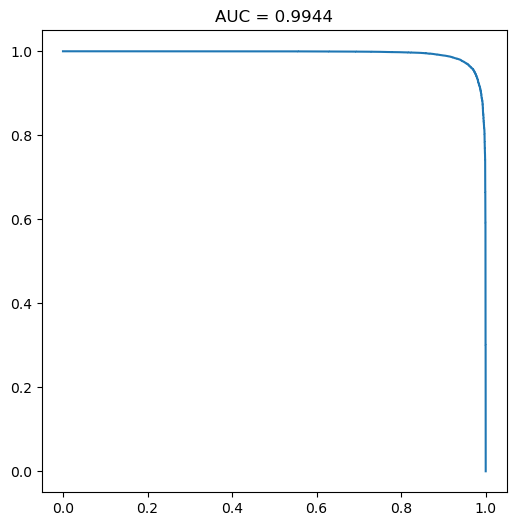

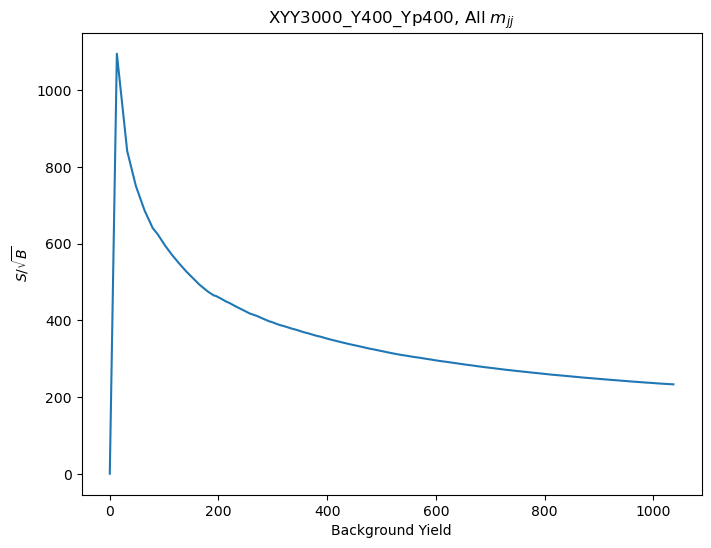

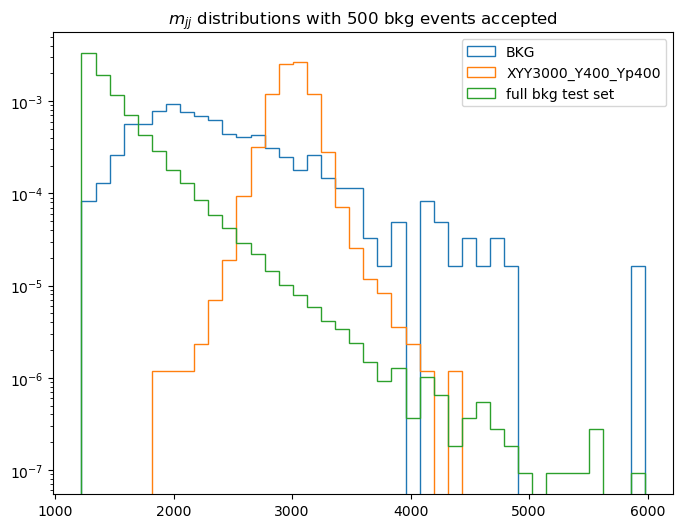

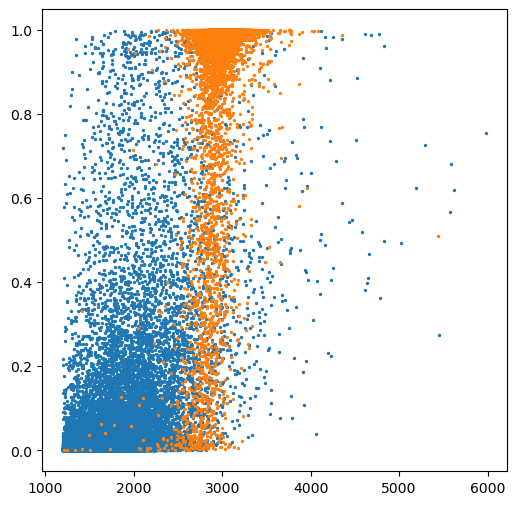

In [9]:
run_training("XYY3000_Y400_Yp400",None,write=False,nTrain_bkg=500000,nTest=100000)

100%|██████████| 1/1 [00:00<00:00, 38.82it/s]


Signal training:  74707
Signal testing:  8301
Bkg training:  100000
Bkg testing:  100000
Train:  174707
Test:  108301
Epoch 10, Loss: 0.6855
Epoch 20, Loss: 0.6801
Epoch 30, Loss: 0.6666
Epoch 40, Loss: 0.6700
Epoch 50, Loss: 0.6640
Mjj_correlation:
[[1.        0.0340707]
 [0.0340707 1.       ]]


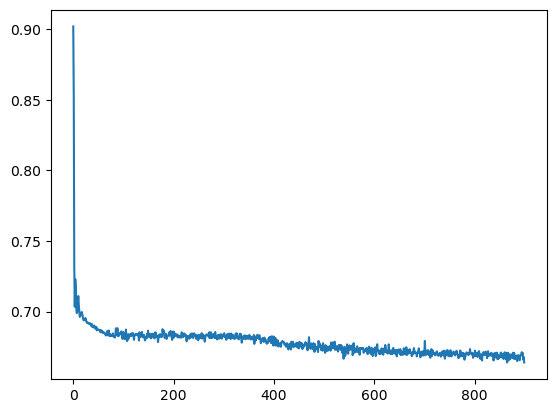

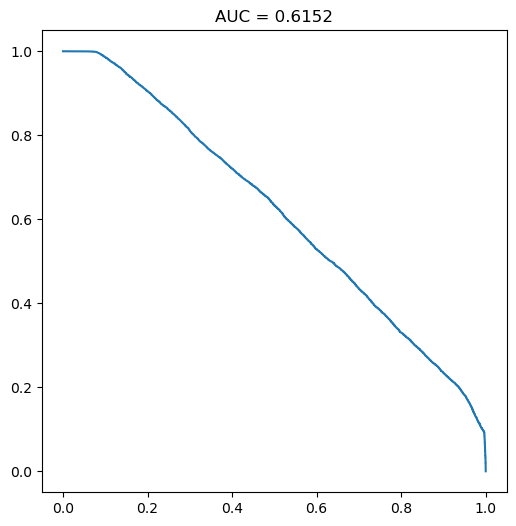

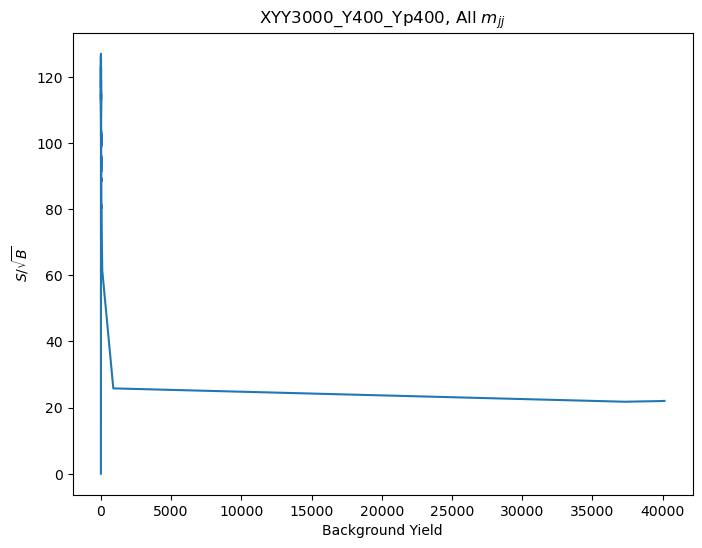

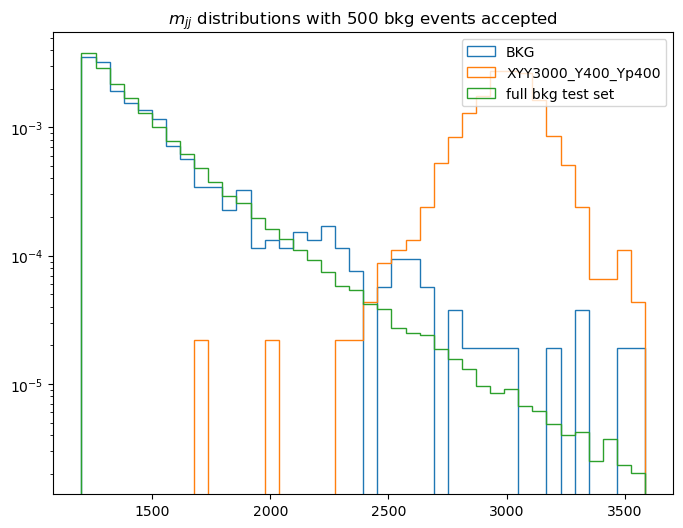

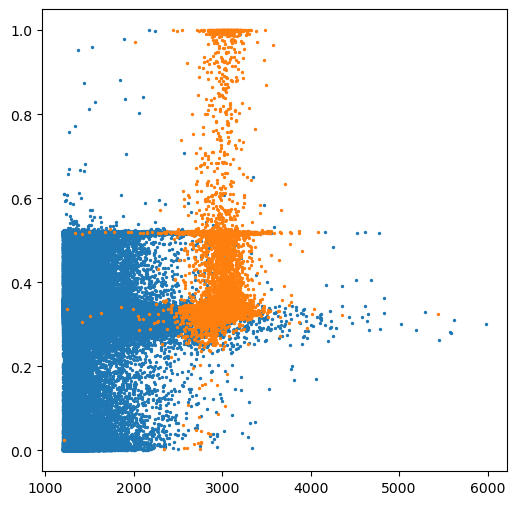

In [6]:
run_training("XYY3000_Y400_Yp400",None,disco=1,write=False,nTrain_bkg=100000,nTest=100000)

# Write trainings

In [7]:
# Wp NNs on XYY data
samples = ["XYY3000_Y400_Yp400","BKG"]
trainings = ["XYY3000_Y400_Yp400_mjjAll_disco"]

variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
variables_mjj = ['mjj']+variables
dirs = ['lossEvals','lossEvals_linearDecorr','lossEvals_linearDecorr_boxCox',
        'lossEvals_pcaDecorr','lossEvals_pcaDecorr_boxCox',
        'lossEvals_noDecorr','lossEvals_noDecorr_boxCox']
from tqdm import tqdm
for t in trainings:
    model = torch.load(f"supervised_trainings/{t}.pt").to(device)
    outName = f"NNScore_{t}"
    for samp in samples:
        sig = loadData(samp,variables_mjj,-1,mode='all',dEta_cut=1.3,sideband=False)
        sig,sig_mjj = sig[:,1:],sig[:,0]
        means, stds = loadMeans(variables)
        sig = (sig-means)/stds
        sig_preds = []
        split = np.array_split(np.arange(len(sig)),len(sig)//50000)
        with torch.no_grad():
            for sp in split:
                sig_preds.append(model(torch.tensor(sig[sp],dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0])
        sig_preds = np.concatenate(sig_preds,axis=0)
        for d in dirs:
            fs = d+f"/{samp}.h5"
            with h5py.File(fs,"r+") as fout:
                if not np.all(fout['mjj'][()]==sig_mjj):
                    print(f"Bad {fs}, mjjs don't match!")
                else:
                    if outName in fout.keys():
                        del fout[outName]
                    fout.create_dataset(outName,data=sig_preds)
    del model
    torch.cuda.empty_cache()

100%|██████████| 80/80 [01:43<00:00,  1.29s/it]


# Neural net in [2500,3500] window

100%|██████████| 1/1 [00:00<00:00, 43.34it/s]


Signal training:  34281
Signal testing:  3781
Bkg training:  47256
Bkg testing:  8791
Train:  81537
Test:  12572
Epoch 10, Loss: 0.1740
Epoch 20, Loss: 0.1668
Epoch 30, Loss: 0.1720
Epoch 40, Loss: 0.1362
Epoch 50, Loss: 0.1692
Mjj_correlation:
[[1.         0.07380996]
 [0.07380996 1.        ]]


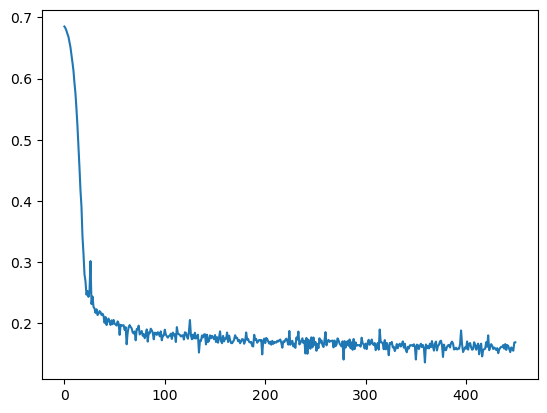

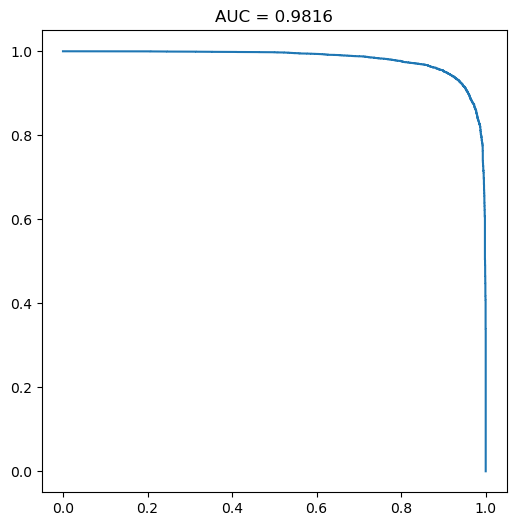

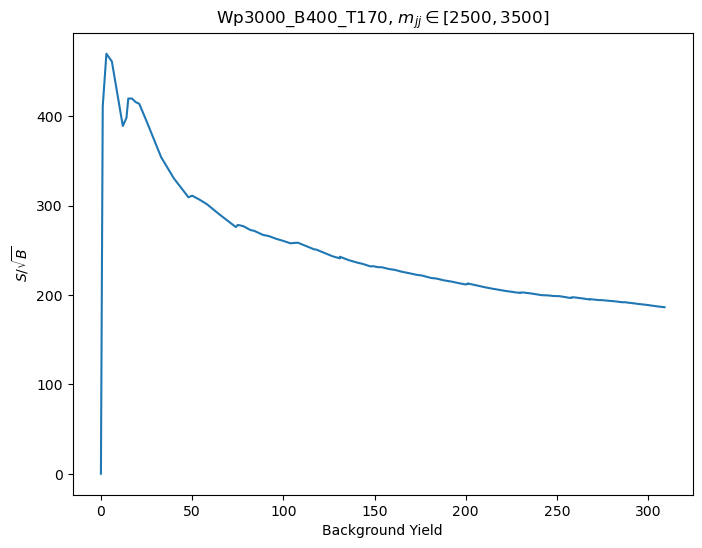

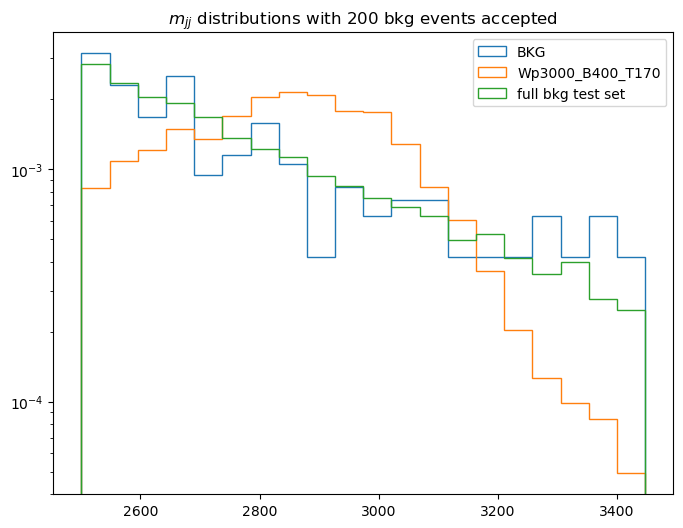

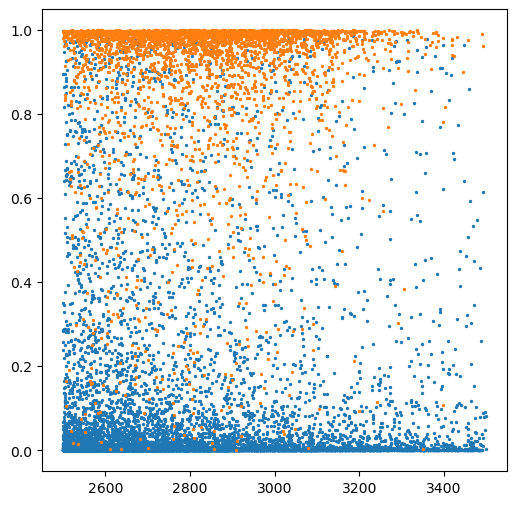

In [30]:
run_training("Wp3000_B400_T170",[2500,3500],write=False,nTrain_bkg=4000000,nTest=1000000)

100%|██████████| 1/1 [00:00<00:00, 40.36it/s]


Signal training:  75618
Signal testing:  8394
Bkg training:  47256
Bkg testing:  8791
Train:  122874
Test:  17185
Epoch 10, Loss: 0.1951
Epoch 20, Loss: 0.1672
Epoch 30, Loss: 0.1553
Epoch 40, Loss: 0.1382
Epoch 50, Loss: 0.1504
Mjj_correlation:
[[1.         0.49986691]
 [0.49986691 1.        ]]


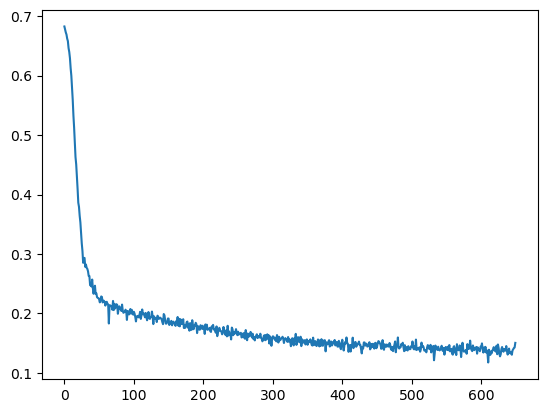

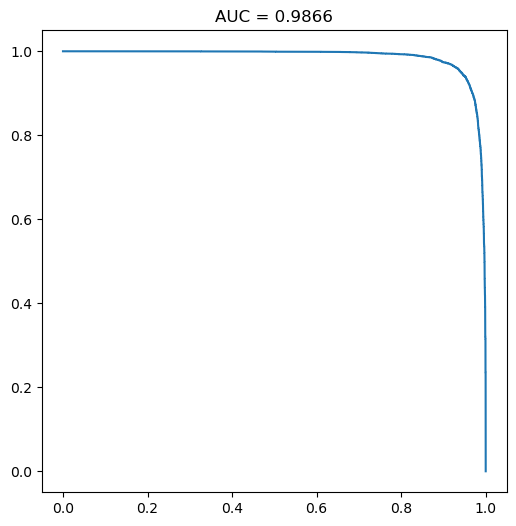

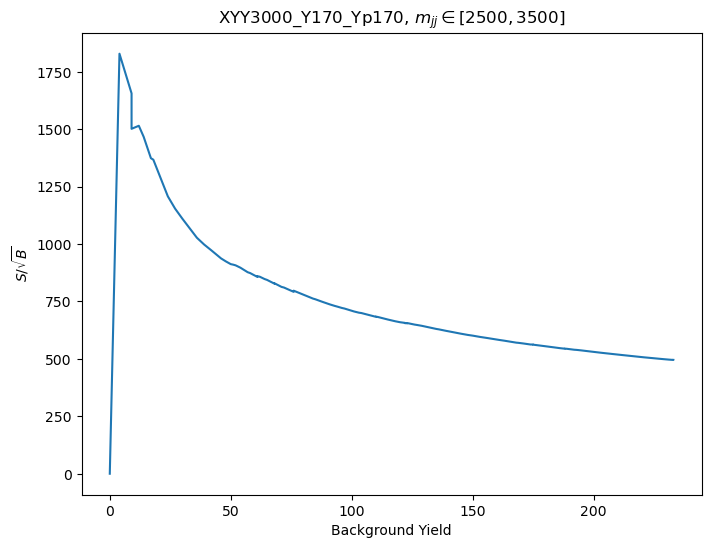

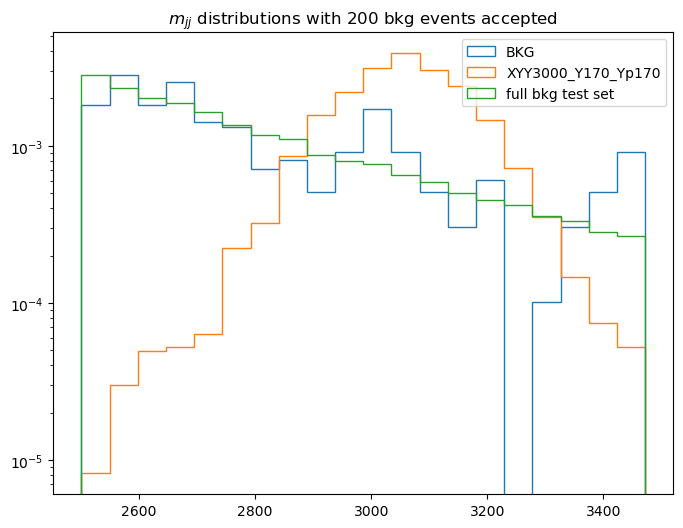

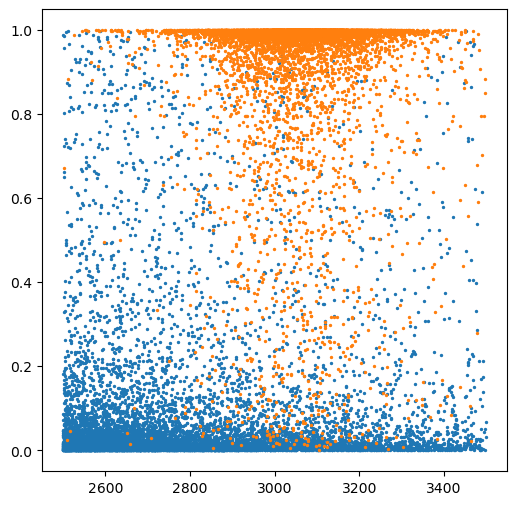

In [31]:
run_training("XYY3000_Y170_Yp170",[2500,3500],write=False,nTrain_bkg=4000000,nTest=1000000)

100%|██████████| 1/1 [00:00<00:00, 44.20it/s]


Signal training:  51541
Signal testing:  5727
Bkg training:  100000
Bkg testing:  100000
Train:  151541
Test:  105727
Epoch 10, Loss: 0.1296
Epoch 20, Loss: 0.1079
Epoch 30, Loss: 0.1332
Epoch 40, Loss: 0.1384
Epoch 50, Loss: 0.1089
Mjj_correlation:
[[1.        0.6632738]
 [0.6632738 1.       ]]


100%|██████████| 40/40 [03:47<00:00,  5.68s/it]


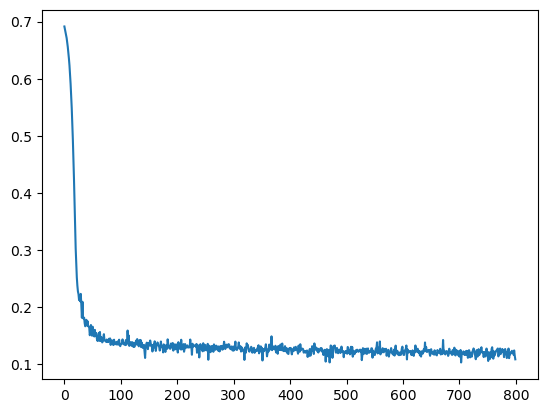

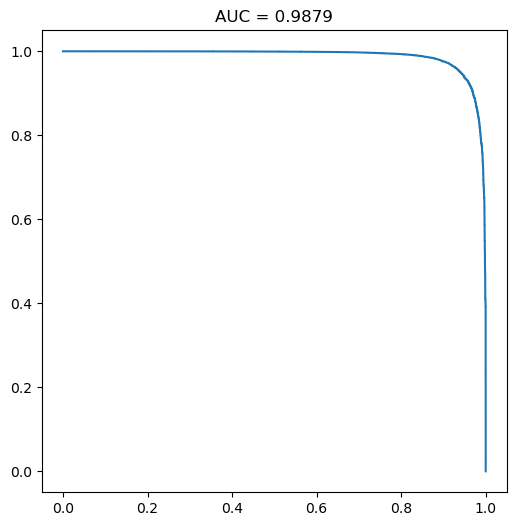

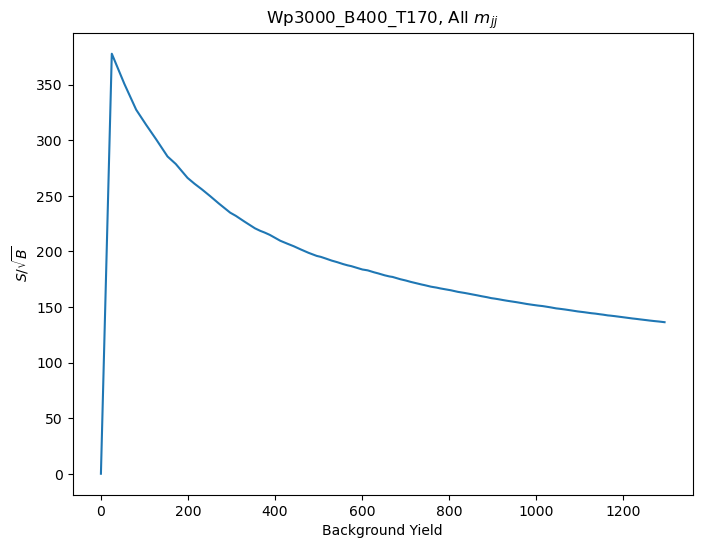

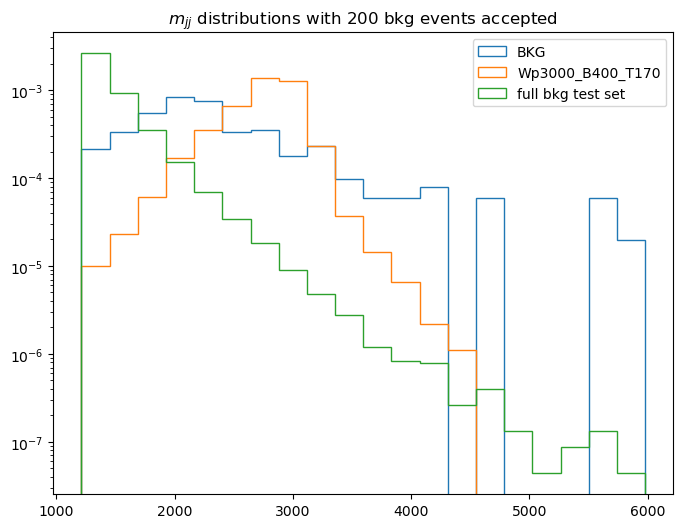

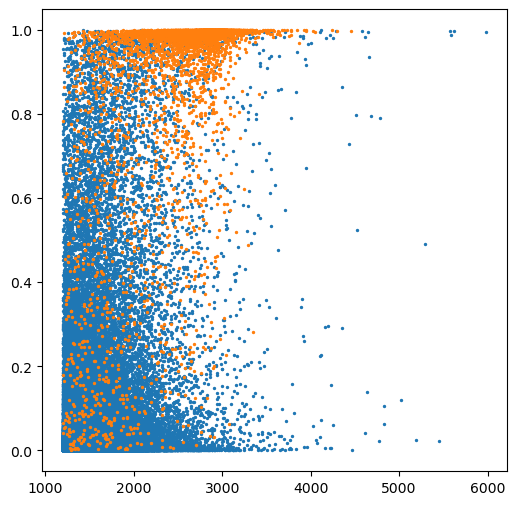

In [37]:
run_training("Wp3000_B400_T170",None,write=True,nTrain_bkg=100000,nTest=100000)

100%|██████████| 1/1 [00:00<00:00, 40.71it/s]


Signal training:  76524
Signal testing:  8503
Bkg training:  100000
Bkg testing:  100000
Train:  176524
Test:  108503
Epoch 10, Loss: 0.0559
Epoch 20, Loss: 0.0498
Epoch 30, Loss: 0.0379
Epoch 40, Loss: 0.0425
Epoch 50, Loss: 0.0318
Mjj_correlation:
[[1.         0.86618694]
 [0.86618694 1.        ]]


100%|██████████| 40/40 [03:39<00:00,  5.49s/it]


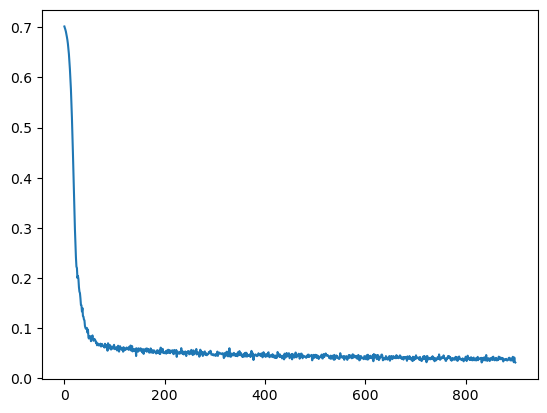

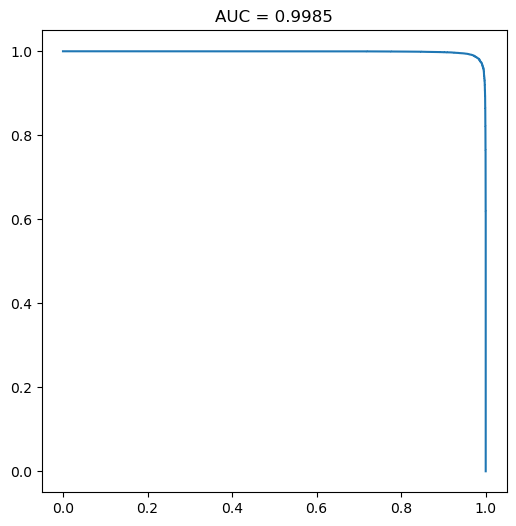

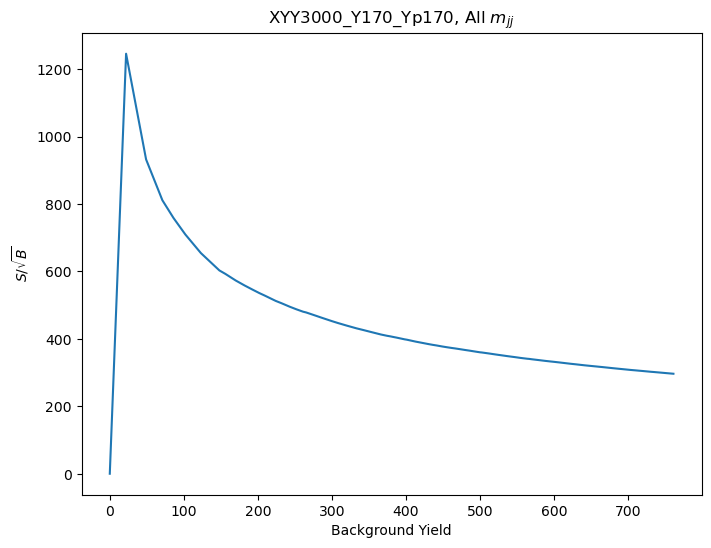

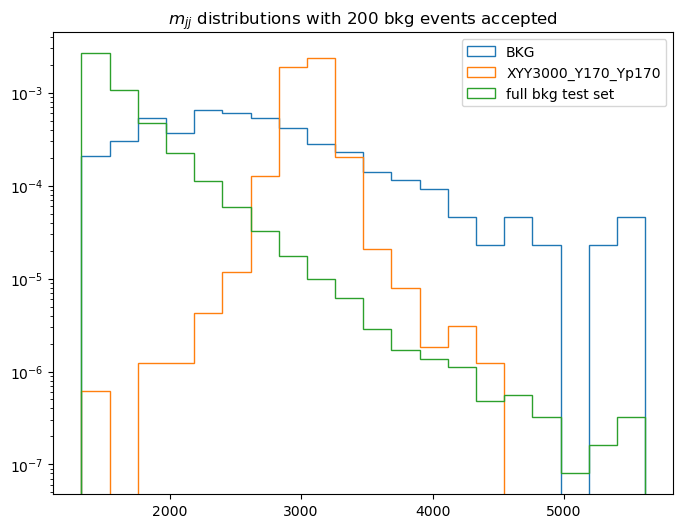

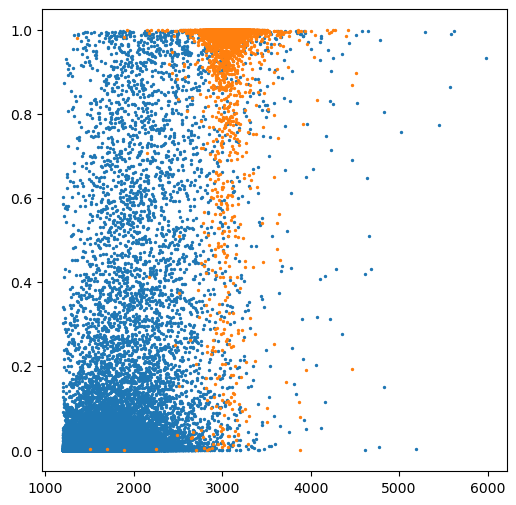

In [38]:
run_training("XYY3000_Y170_Yp170",None,write=True,nTrain_bkg=100000,nTest=100000)

100%|██████████| 1/1 [00:00<00:00, 44.43it/s]


Signal training:  34281
Signal testing:  3781
Bkg training:  47256
Bkg testing:  8791
Train:  81537
Test:  12572
Epoch 10, Loss: 0.4550
Epoch 20, Loss: 0.3473
Epoch 30, Loss: 0.3502
Epoch 40, Loss: 0.3163
Epoch 50, Loss: 0.3656
Mjj_correlation:
[[1.         0.01130085]
 [0.01130085 1.        ]]


100%|██████████| 1/1 [00:00<00:00,  2.88it/s]


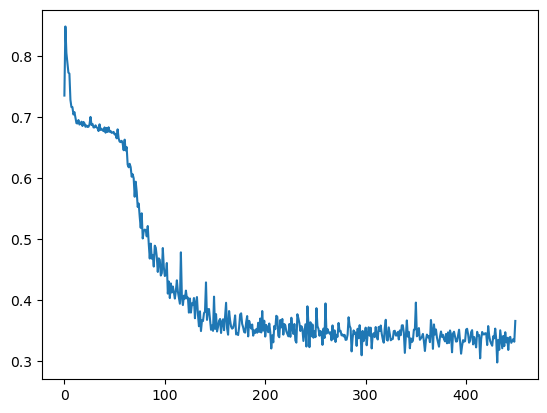

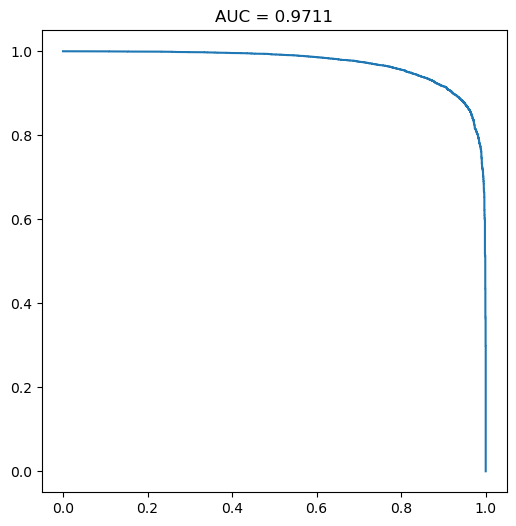

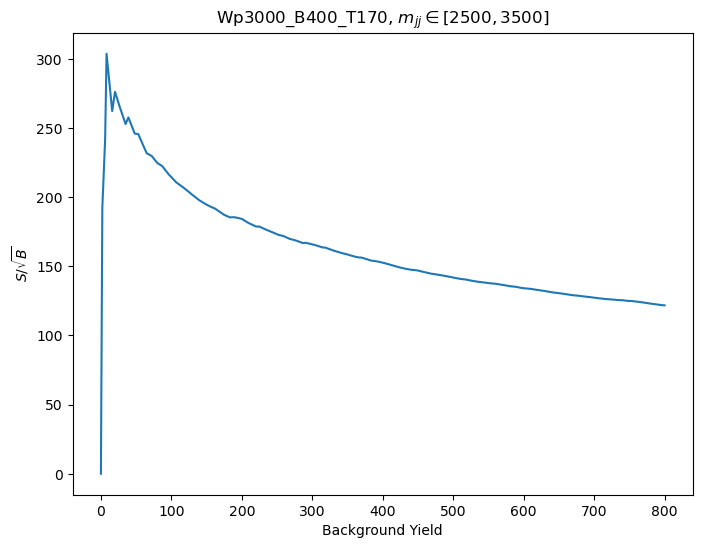

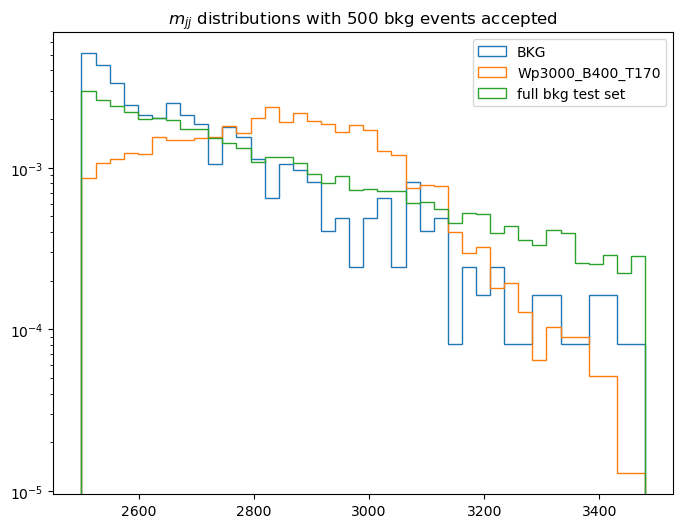

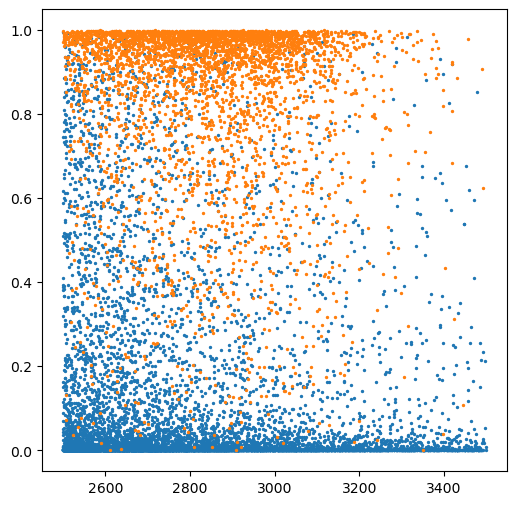

In [6]:
run_training("Wp3000_B400_T170",[2500,3500],disco=7,write=True,nTrain_bkg=4000000,nTest=1000000)

100%|██████████| 1/1 [00:00<00:00, 39.75it/s]


Signal training:  75618
Signal testing:  8394
Bkg training:  47256
Bkg testing:  8791
Train:  122874
Test:  17185
Epoch 10, Loss: 0.6665
Epoch 20, Loss: 0.6089
Epoch 30, Loss: 0.5351
Epoch 40, Loss: 0.5575
Epoch 50, Loss: 0.5367
Mjj_correlation:
[[1.         0.13481478]
 [0.13481478 1.        ]]


100%|██████████| 1/1 [00:00<00:00,  2.10it/s]


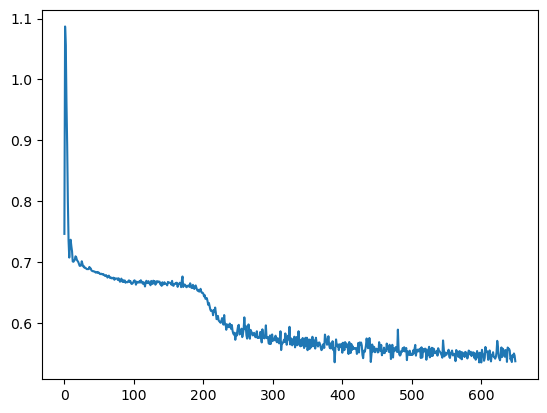

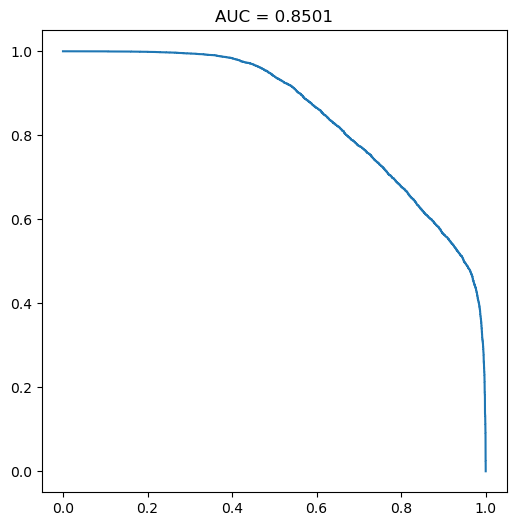

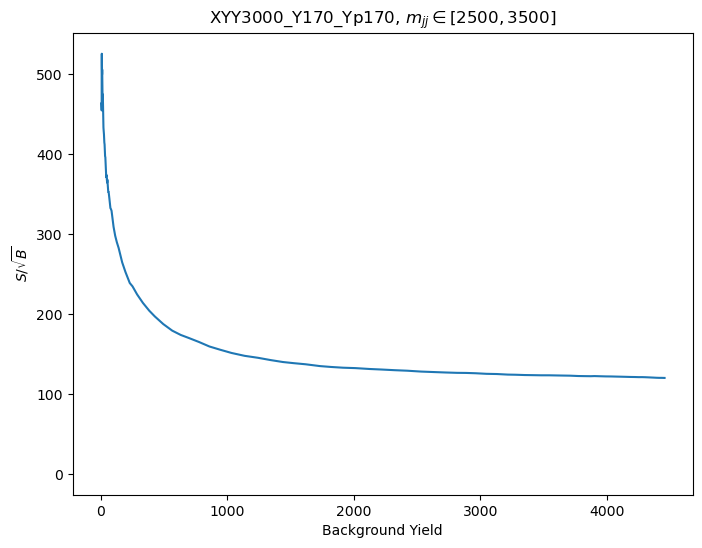

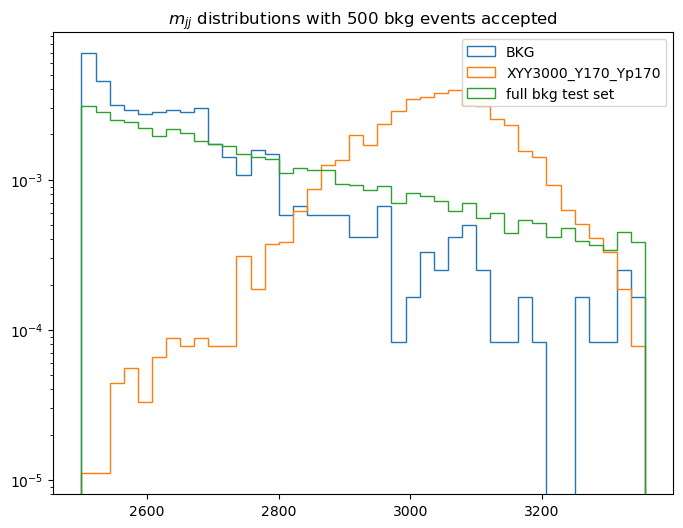

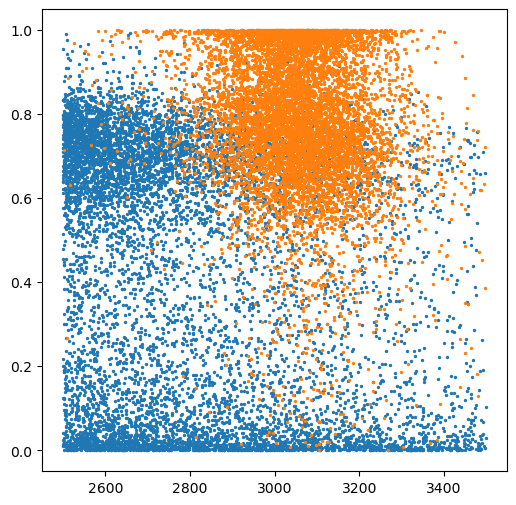

In [7]:
run_training("XYY3000_Y170_Yp170",[2500,3500],disco=2,write=True,nTrain_bkg=4000000,nTest=1000000)

100%|██████████| 1/1 [00:00<00:00, 46.70it/s]


Signal training:  51541
Signal testing:  5727
Bkg training:  100000
Bkg testing:  100000
Train:  151541
Test:  105727
Epoch 10, Loss: 0.4946
Epoch 20, Loss: 0.4713
Epoch 30, Loss: 0.4799
Epoch 40, Loss: 0.4499
Epoch 50, Loss: 0.4420
Mjj_correlation:
[[1.         0.41829268]
 [0.41829268 1.        ]]


100%|██████████| 40/40 [03:06<00:00,  4.65s/it]


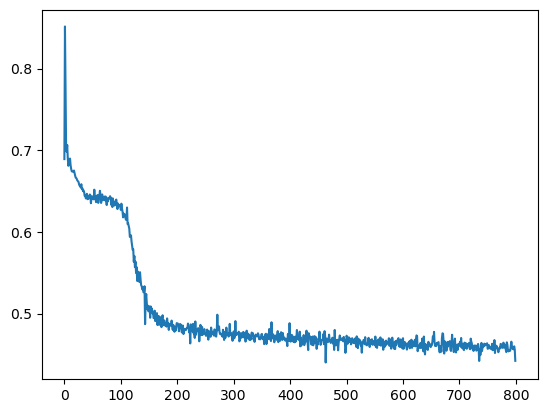

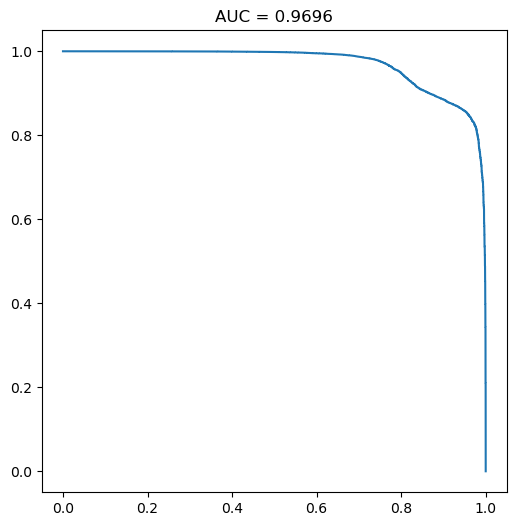

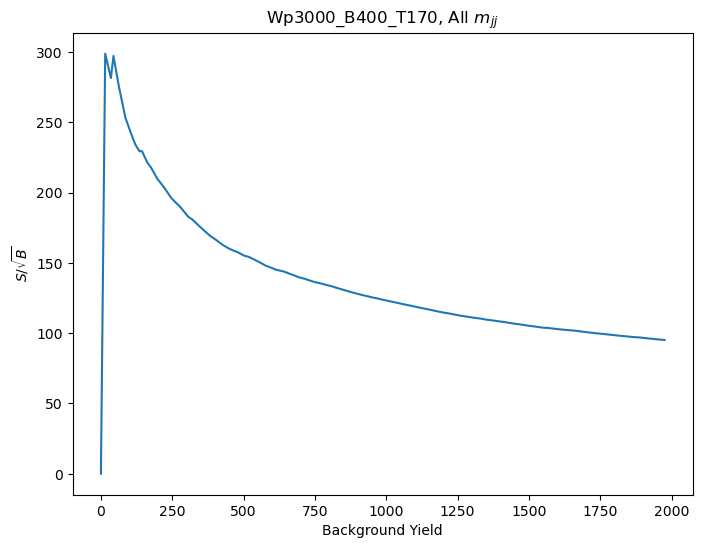

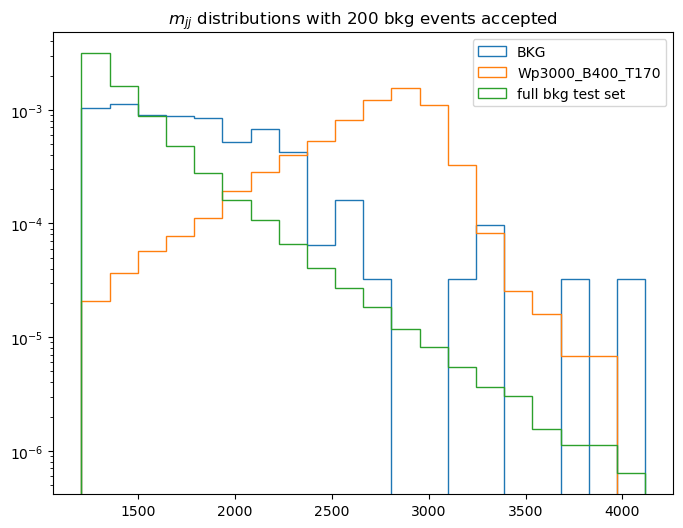

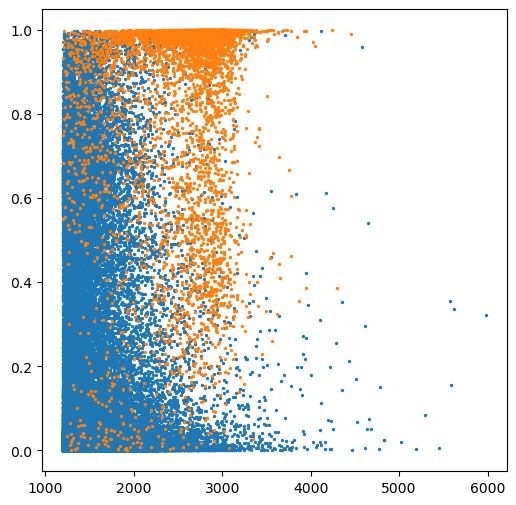

In [6]:
run_training("Wp3000_B400_T170",None,disco=0.5,write=True,nTrain_bkg=100000,nTest=100000)

100%|██████████| 1/1 [00:00<00:00, 41.33it/s]


Signal training:  76524
Signal testing:  8503
Bkg training:  100000
Bkg testing:  100000
Train:  176524
Test:  108503
Epoch 10, Loss: 0.6131
Epoch 20, Loss: 0.5009
Epoch 30, Loss: 0.5047
Epoch 40, Loss: 0.5033
Epoch 50, Loss: 0.4924
Mjj_correlation:
[[1.         0.84137302]
 [0.84137302 1.        ]]


100%|██████████| 1/1 [00:00<00:00,  3.18it/s]


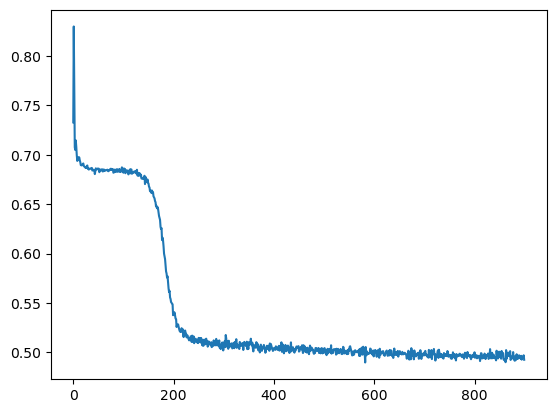

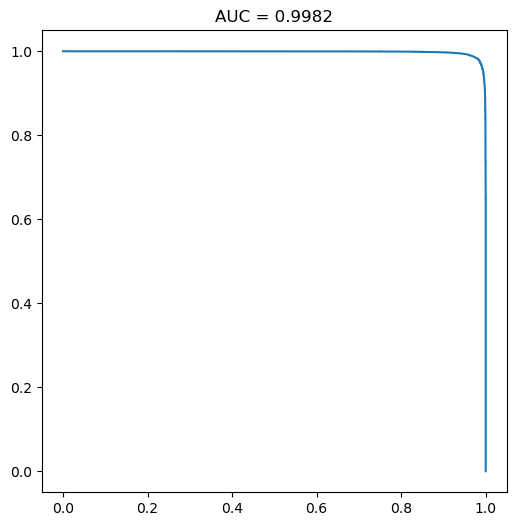

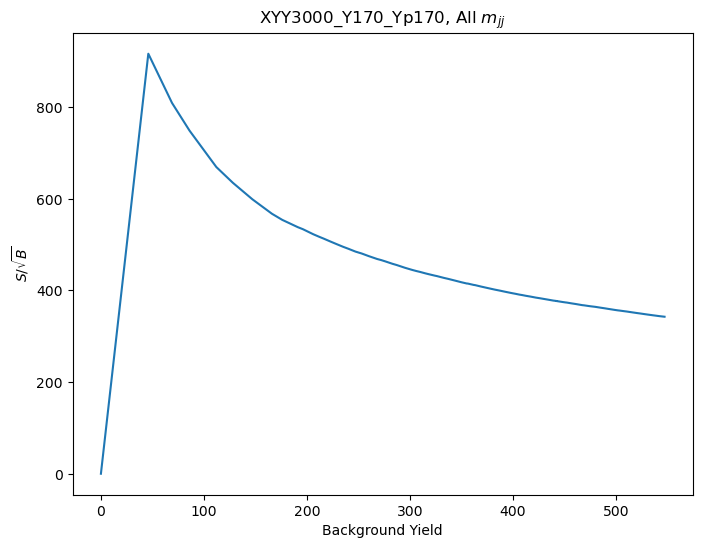

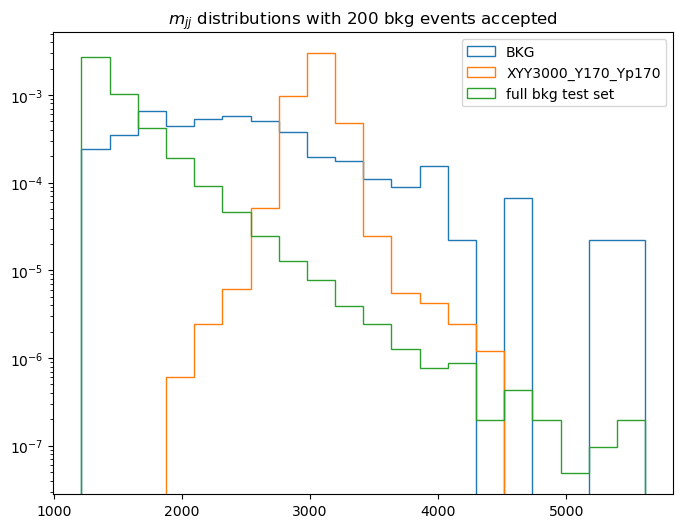

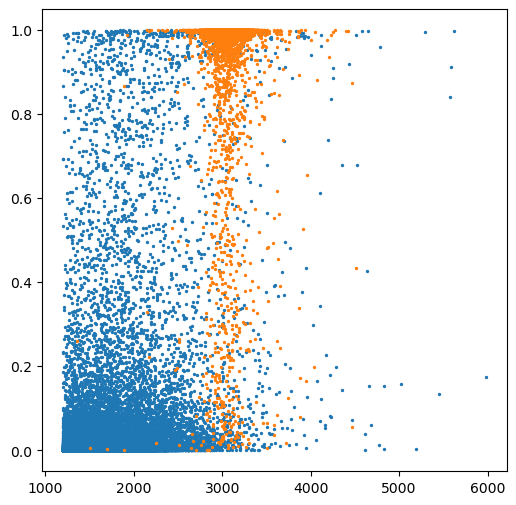

In [6]:
run_training("XYY3000_Y170_Yp170",None,disco=0.5,write=True,nTrain_bkg=100000,nTest=100000)

100%|██████████| 1/1 [00:00<00:00, 44.11it/s]


Signal training:  99999
Signal testing:  16222
Bkg training:  100000
Bkg testing:  100000
Train:  199999
Test:  116222
Epoch 10, Loss: 0.1767
Epoch 20, Loss: 0.1724
Epoch 30, Loss: 0.1650
Epoch 40, Loss: 0.1541
Epoch 50, Loss: 0.1606
Mjj_correlation:
[[1.         0.63138649]
 [0.63138649 1.        ]]


100%|██████████| 1/1 [00:00<00:00,  3.82it/s]


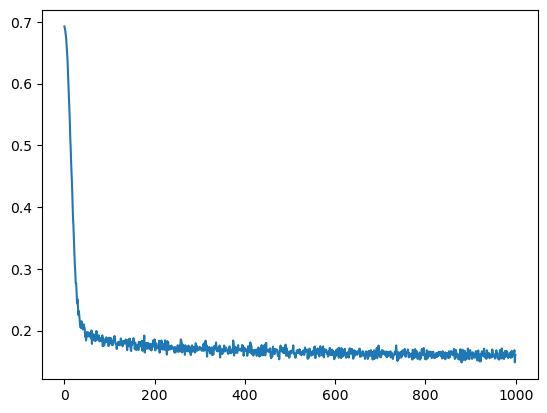

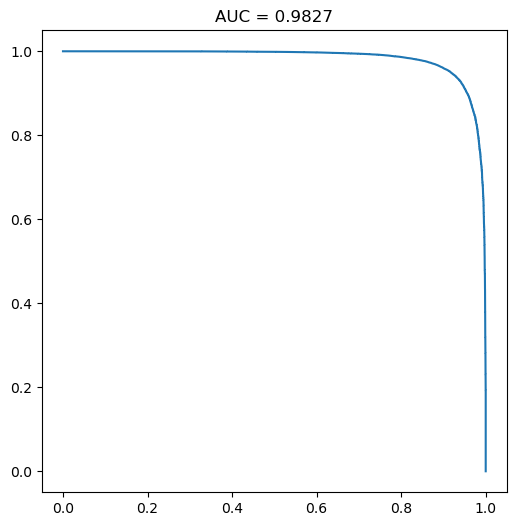

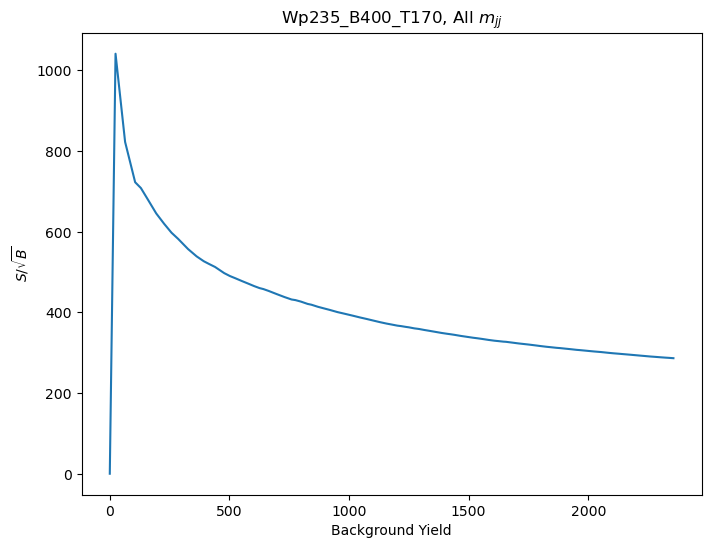

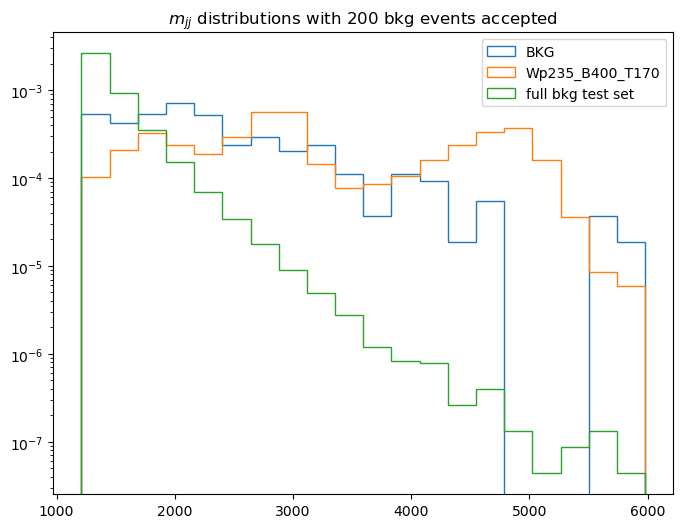

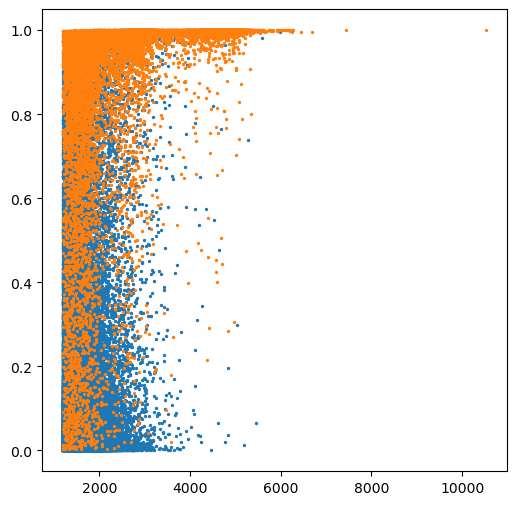

In [4]:
run_training(["Wp2000_B400_T170","Wp3000_B400_T170","Wp5000_B400_T170"],None,alias="Wp235_B400_T170",write=True,nTrain_bkg=100000,nTest=100000)

100%|██████████| 1/1 [00:00<00:00, 39.84it/s]


Signal training:  99999
Signal testing:  25440
Bkg training:  100000
Bkg testing:  100000
Train:  199999
Test:  125440
Epoch 10, Loss: 0.1171
Epoch 20, Loss: 0.0972
Epoch 30, Loss: 0.0872
Epoch 40, Loss: 0.0944
Epoch 50, Loss: 0.0866
Mjj_correlation:
[[1.        0.7868335]
 [0.7868335 1.       ]]


100%|██████████| 1/1 [00:00<00:00,  2.85it/s]


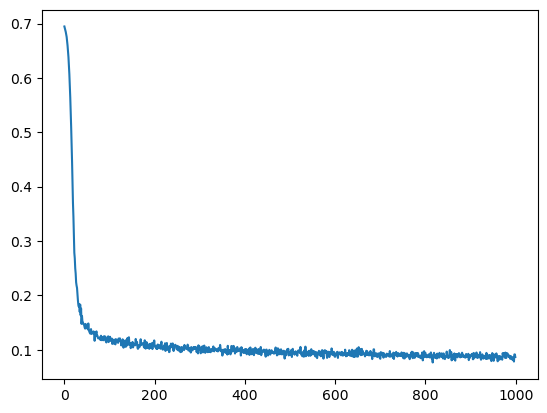

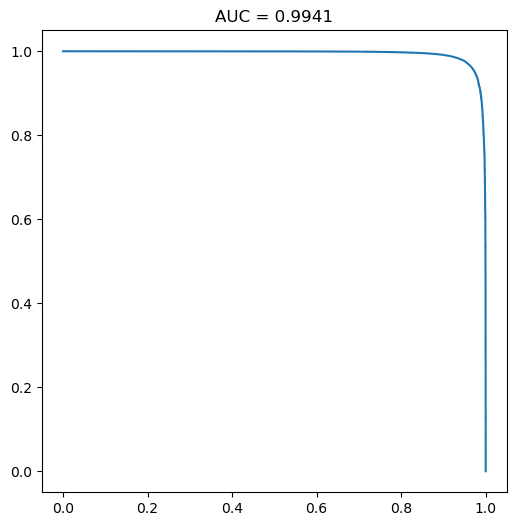

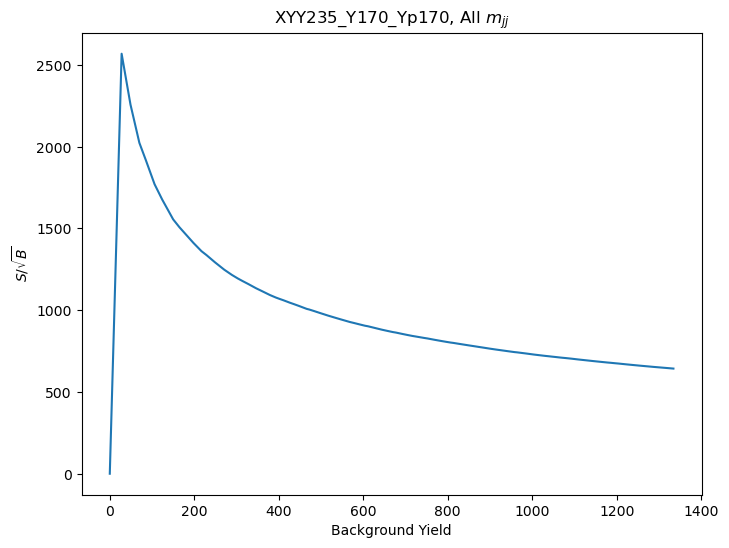

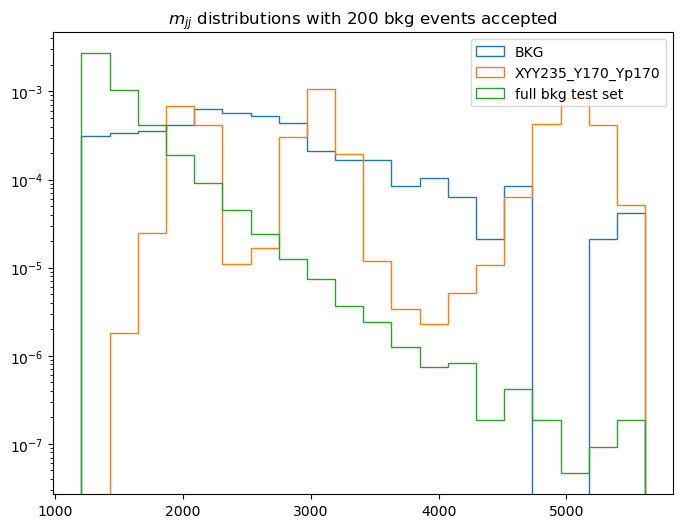

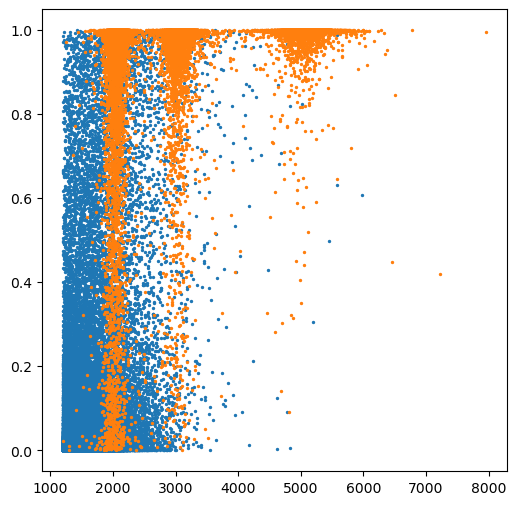

In [5]:
run_training(["XYY2000_Y170_Yp170","XYY3000_Y170_Yp170","XYY5000_Y170_Yp170"],None,alias="XYY235_Y170_Yp170",write=True,nTrain_bkg=100000,nTest=100000)

100%|██████████| 1/1 [00:00<00:00, 44.05it/s]


Signal training:  99999
Signal testing:  16222
Bkg training:  100000
Bkg testing:  100000
Train:  199999
Test:  116222
Epoch 10, Loss: 0.4833
Epoch 20, Loss: 0.4523
Epoch 30, Loss: 0.4526
Epoch 40, Loss: 0.4478
Epoch 50, Loss: 0.4369
Mjj_correlation:
[[1.         0.32209688]
 [0.32209688 1.        ]]


100%|██████████| 1/1 [00:00<00:00,  3.78it/s]


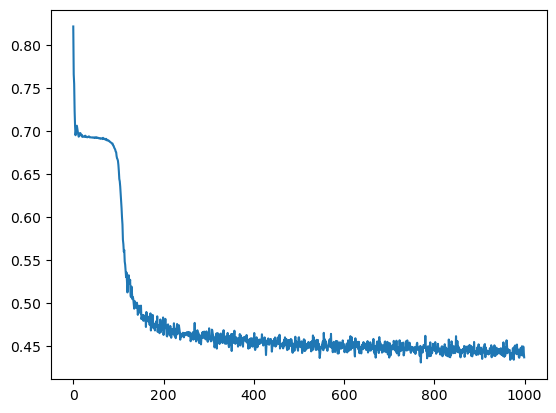

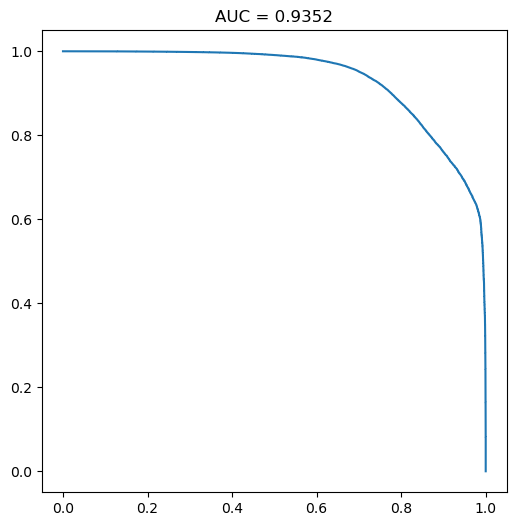

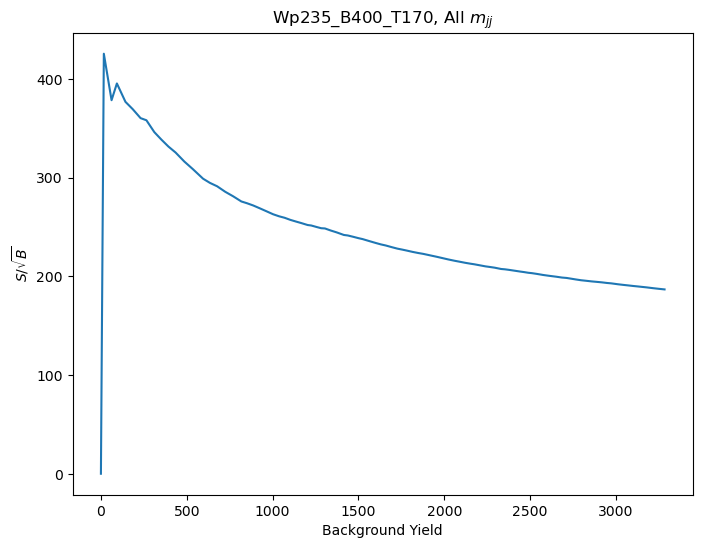

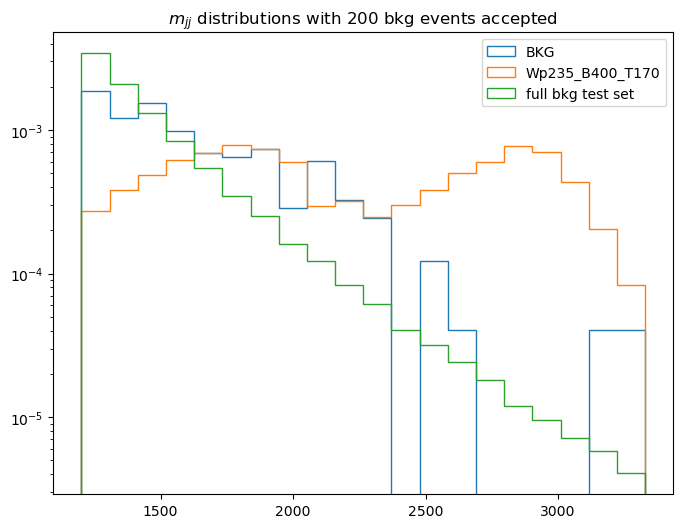

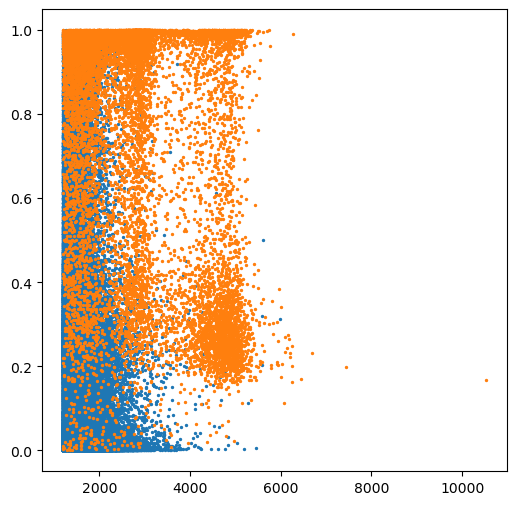

In [6]:
run_training(["Wp2000_B400_T170","Wp3000_B400_T170","Wp5000_B400_T170"],None,alias="Wp235_B400_T170",disco=1,write=True,nTrain_bkg=100000,nTest=100000)

100%|██████████| 1/1 [00:00<00:00, 41.41it/s]


Signal training:  99999
Signal testing:  25440
Bkg training:  100000
Bkg testing:  100000
Train:  199999
Test:  125440
Epoch 10, Loss: 0.5847
Epoch 20, Loss: 0.5363
Epoch 30, Loss: 0.5309
Epoch 40, Loss: 0.5331
Epoch 50, Loss: 0.5203
Mjj_correlation:
[[1.         0.39965291]
 [0.39965291 1.        ]]


100%|██████████| 1/1 [00:00<00:00,  3.17it/s]


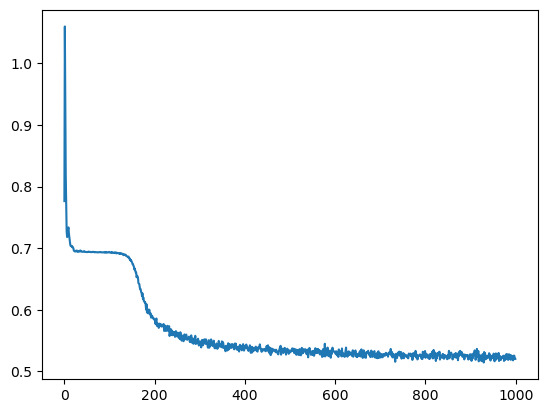

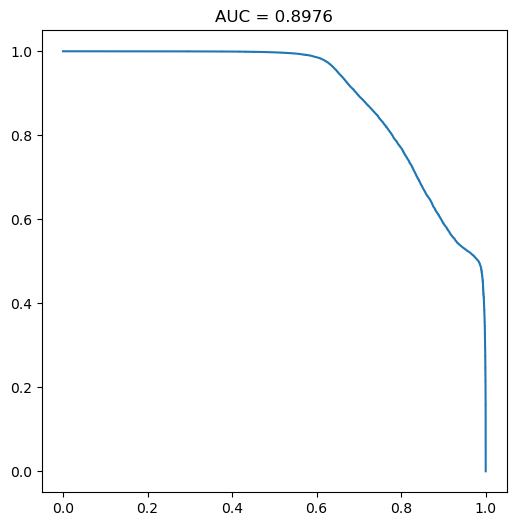

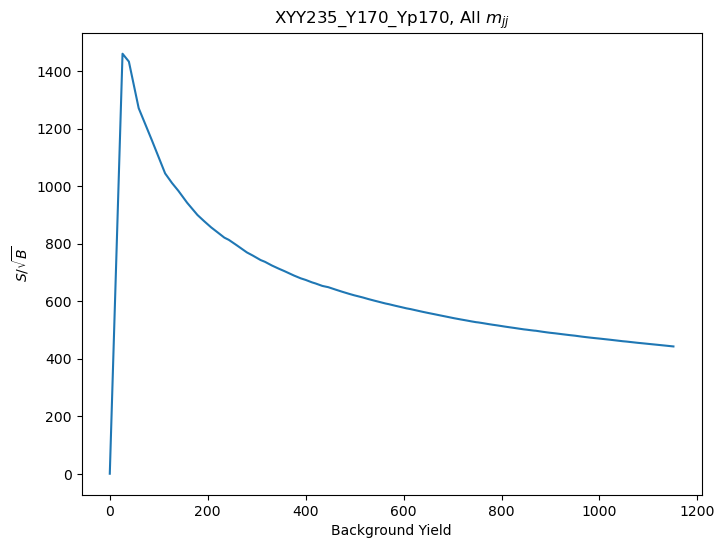

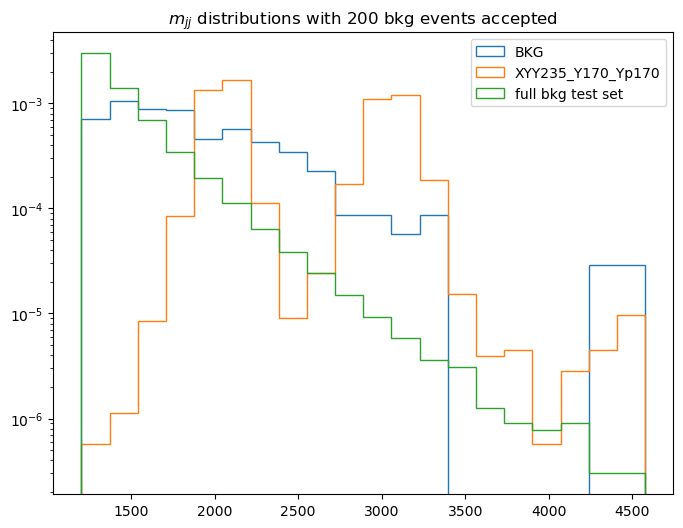

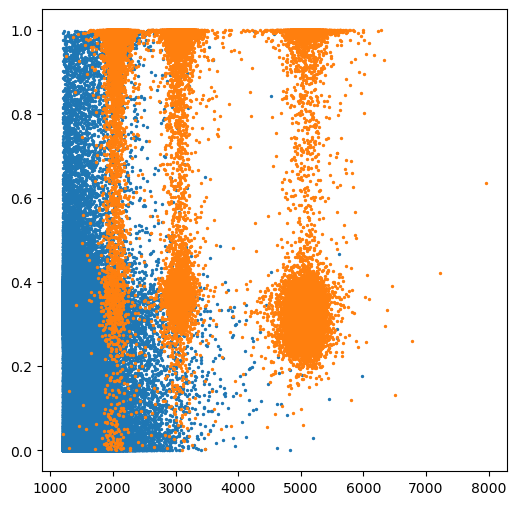

In [7]:
run_training(["XYY2000_Y170_Yp170","XYY3000_Y170_Yp170","XYY5000_Y170_Yp170"],None,alias="XYY235_Y170_Yp170",disco=1,write=True,nTrain_bkg=100000,nTest=100000)

# Some additional NN evaluations

In [9]:
# Wp NNs on XYY data
samples = ["XYY2000_Y170_Yp170","XYY3000_Y170_Yp170","XYY5000_Y170_Yp170"]
trainings = ["Wp3000_B400_T170_mjj2500-3500","Wp3000_B400_T170_mjjAll","Wp3000_B400_T170_mjj2500-3500_disco","Wp3000_B400_T170_mjjAll_disco"]

variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
variables_mjj = ['mjj']+variables
dirs = ['lossEvals','lossEvals_linearDecorr','lossEvals_linearDecorr_boxCox',
        'lossEvals_pcaDecorr','lossEvals_pcaDecorr_boxCox',
        'lossEvals_noDecorr','lossEvals_noDecorr_boxCox']
for t in trainings:
    model = torch.load(f"supervised_trainings/{t}.pt").to(device)
    outName = f"NNScore_{t}"
    for samp in samples:
        sig = loadData(samp,variables_mjj,-1,mode='all',dEta_cut=1.3,sideband=False)
        sig,sig_mjj = sig[:,1:],sig[:,0]
        means, stds = loadMeans(variables)
        sig = (sig-means)/stds
        sig_preds = model(torch.tensor(sig,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0]
        for d in dirs:
            fs = d+f"/{samp}.h5"
            with h5py.File(fs,"r+") as fout:
                if not np.all(fout['mjj'][()]==sig_mjj):
                    print(f"Bad {fs}, mjjs don't match!")
                else:
                    if outName in fout.keys():
                        del fout[outName]
                    fout.create_dataset(outName,data=sig_preds)
    del model
    torch.cuda.empty_cache()

100%|██████████| 1/1 [00:00<00:00, 40.91it/s]


In [10]:
# Xyy NNs on Wp data
samples = ["Wp2000_B400_T170","Wp3000_B400_T170","Wp5000_B400_T170"]
trainings = ["XYY3000_Y170_Yp170_mjj2500-3500","XYY3000_Y170_Yp170_mjjAll","XYY3000_Y170_Yp170_mjj2500-3500_disco","XYY3000_Y170_Yp170_mjjAll_disco"]

variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
variables_mjj = ['mjj']+variables
dirs = ['lossEvals','lossEvals_linearDecorr','lossEvals_linearDecorr_boxCox',
        'lossEvals_pcaDecorr','lossEvals_pcaDecorr_boxCox',
        'lossEvals_noDecorr','lossEvals_noDecorr_boxCox']
for t in trainings:
    model = torch.load(f"supervised_trainings/{t}.pt").to(device)
    outName = f"NNScore_{t}"
    for samp in samples:
        sig = loadData(samp,variables_mjj,-1,mode='all',dEta_cut=1.3,sideband=False)
        sig,sig_mjj = sig[:,1:],sig[:,0]
        sig_preds = model(torch.tensor(sig,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0]
        for d in dirs:
            fs = d+f"/{samp}.h5"
            with h5py.File(fs,"r+") as fout:
                if not np.all(fout['mjj'][()]==sig_mjj):
                    print(f"Bad {fs}, mjjs don't match!")
                else:
                    if outName in fout.keys():
                        del fout[outName]
                    fout.create_dataset(outName,data=sig_preds)
    del model
    torch.cuda.empty_cache()

100%|██████████| 1/1 [00:00<00:00, 44.82it/s]


In [12]:
# everything on everything
samples = ["XYY2000_Y170_Yp170","XYY3000_Y170_Yp170","XYY5000_Y170_Yp170",
           "Wp2000_B400_T170","Wp3000_B400_T170","Wp5000_B400_T170"]
trainings = ["Wp3000_B400_T170_mjj2500-3500","Wp3000_B400_T170_mjjAll","Wp3000_B400_T170_mjj2500-3500_disco","Wp3000_B400_T170_mjjAll_disco",
            "XYY3000_Y170_Yp170_mjj2500-3500","XYY3000_Y170_Yp170_mjjAll","XYY3000_Y170_Yp170_mjj2500-3500_disco","XYY3000_Y170_Yp170_mjjAll_disco",
            "Wp235_B400_T170_mjjAll","XYY235_Y170_Yp170_mjjAll","XYY235_Y170_Yp170_mjjAll","XYY235_Y170_Yp170_mjjAll_disco","XYY3000_Y170_Yp170_mjjAll_disco"]
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
variables_mjj = ['mjj']+variables
dirs = ['lossEvals','lossEvals_linearDecorr','lossEvals_linearDecorr_boxCox',
        'lossEvals_pcaDecorr','lossEvals_pcaDecorr_boxCox',
        'lossEvals_noDecorr','lossEvals_noDecorr_boxCox']
for t in trainings:
    model = torch.load(f"supervised_trainings/{t}.pt").to(device)
    outName = f"NNScore_{t}"
    for samp in samples:
        sig = loadData(samp,variables_mjj,-1,mode='all',dEta_cut=1.3,sideband=False)
        sig,sig_mjj = sig[:,1:],sig[:,0]
        sig_preds = model(torch.tensor(sig,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0]
        for d in dirs:
            fs = d+f"/{samp}.h5"
            with h5py.File(fs,"r+") as fout:
                if not np.all(fout['mjj'][()]==sig_mjj):
                    print(f"Bad {fs}, mjjs don't match!")
                else:
                    if outName in fout.keys():
                        del fout[outName]
                    fout.create_dataset(outName,data=sig_preds)
    del model
    torch.cuda.empty_cache()

100%|██████████| 1/1 [00:00<00:00, 49.41it/s]


# QUAK in [2500,3500] window

In [58]:
f_sig = 'lossEvals_pcaDecorr_boxCox/Wp3000_B400_T170.h5'
f_bkg = 'lossEvals_pcaDecorr_boxCox/BKG.h5'

with h5py.File(f_sig,"r") as fin:
    m_sig = fin['mjj'][()]
    lb_sig = fin['BKG_mjjFlat'][()]
    ls_sig = fin['Wp3000_B400_T170'][()]
with h5py.File(f_bkg,"r") as fin:
    m_bkg = fin['mjj'][()]
    lb_bkg = fin['BKG_mjjFlat'][()]
    ls_bkg = fin['Wp3000_B400_T170'][()]
    
cut_sig = (m_sig>2500)&(m_sig<3500)
cut_bkg = (m_bkg>2500)&(m_bkg<3500)


m_sig = m_sig[cut_sig]
lb_sig = lb_sig[cut_sig]
ls_sig = ls_sig[cut_sig]
t = int(0.75*m_sig.shape[0])
m_sig = m_sig[t:]
lb_sig = lb_sig[t:]
ls_sig = ls_sig[t:]

m_bkg = m_bkg[cut_bkg]
lb_bkg = lb_bkg[cut_bkg]
ls_bkg = ls_bkg[cut_bkg]
t = int(0.75*m_bkg.shape[0])
m_bkg = m_bkg[t:]
lb_bkg = lb_bkg[t:]
ls_bkg = ls_bkg[t:]

In [59]:
bmax,bmin = max(lb_sig.max(),lb_bkg.max()),min(lb_sig.min(),lb_bkg.min())
smax,smin = max(ls_sig.max(),ls_bkg.max()),min(ls_sig.min(),ls_bkg.min())

cut_s = np.linspace(smin,smax,100)
cut_b = np.linspace(bmin,bmax,100)

eff_sig = []
eff_bkg = []
for tb in cut_b:
    for ts in cut_s:
        nb = np.count_nonzero((lb_bkg>tb) & (ls_bkg<ts))
        ns = np.count_nonzero((lb_sig>tb) & (ls_sig<ts))
        eff_sig.append(ns/len(m_sig))
        eff_bkg.append(nb/len(m_bkg))

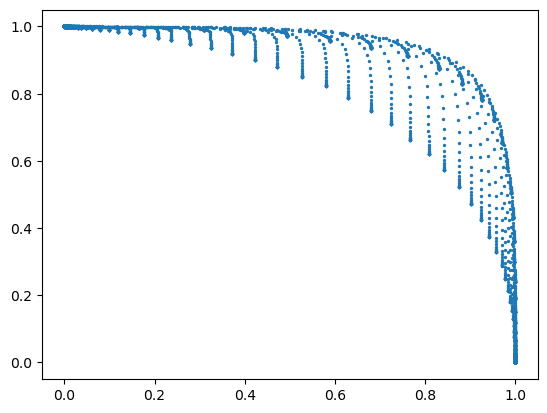

In [60]:
plt.scatter(np.array(eff_sig),1-np.array(eff_bkg),s=2)

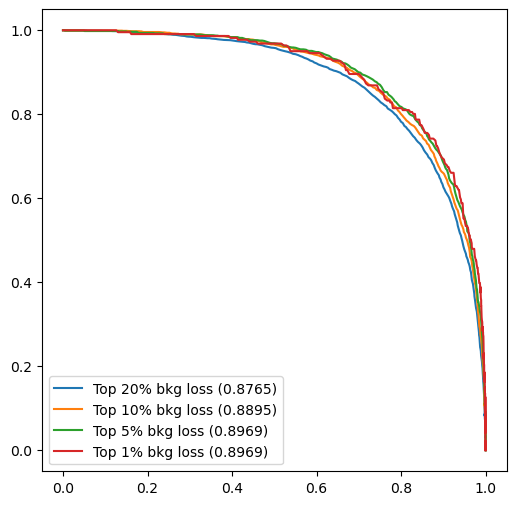

In [61]:
cut_s = np.linspace(smin,smax,1000)
quantiles = [0.8,0.9,0.95,0.99]
#cut_b = np.quantile(np.concatenate((lb_bkg,lb_sig),axis=0),quantiles)
cut_b = np.quantile(lb_bkg,quantiles)

eff_sig = []
eff_bkg = []
val = []
byields = []
mass200_sig = []
mass200_bkg = []
for tb in cut_b:
    es = []
    eb = []
    v = []
    by = []
    db = np.count_nonzero(lb_bkg>tb)
    ds = np.count_nonzero(lb_sig>tb)
    is200 = False
    m200_s = []
    m200_b = []
    for ts in cut_s:
        nb = np.count_nonzero((lb_bkg>tb) & (ls_bkg<ts))
        ns = np.count_nonzero((lb_sig>tb) & (ls_sig<ts))
        es.append(ns/ds)
        eb.append(nb/db)
        by.append(nb)
        if nb > 0:
            v.append(ns/np.sqrt(nb))
        else:
            v.append(np.inf if ns > 0 else 0)
        if nb>200 and not is200:
            m200_b = m_bkg[(lb_bkg>tb) & (ls_bkg<ts)]
            m200_s = m_sig[(lb_sig>tb) & (ls_sig<ts)]
            is200 = True
    eff_sig.append(es)
    eff_bkg.append(eb)
    val.append(v)
    byields.append(by)
    mass200_sig.append(m200_s)
    mass200_bkg.append(m200_b)

plt.figure(figsize=(6,6))
for i,q in enumerate(quantiles):
    srt = np.argsort(eff_sig[i])
    tpr = np.array(eff_sig[i])[srt]
    rej = 1-np.array(eff_bkg[i])[srt]
    auc = np.trapz(rej,tpr)
    plt.plot(tpr,rej,color=f"C{i}",label=f"Top {100*(1-q):.0f}% bkg loss ({auc:.4f})")
    plt.legend(loc='lower left')
    

(0.0, 500.0)

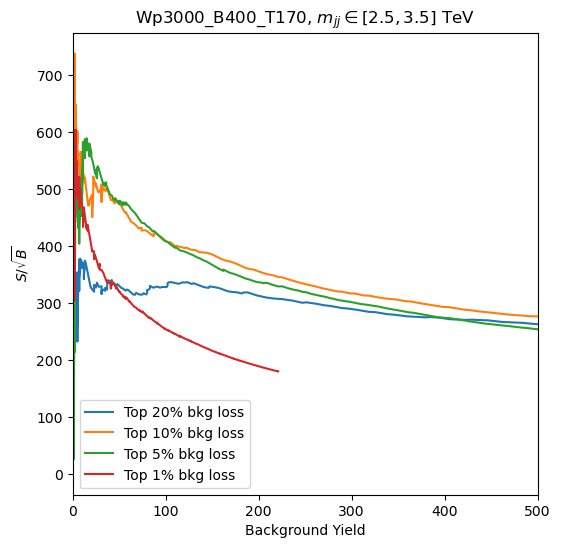

In [62]:
plt.figure(figsize=(6,6))
for i,q in enumerate(quantiles):
    srt = np.argsort(byields[i])
    x = np.array(byields[i])[srt]
    y = np.array(val[i])[srt]
    plt.plot(x,y,color=f"C{i}",label=f"Top {100*(1-q):.0f}% bkg loss")
plt.legend(loc='lower left')
plt.xlabel('Background Yield')
plt.ylabel(r"$S/\sqrt{B}$")
plt.title(r"Wp3000_B400_T170, $m_{jj} \in [2.5,3.5]$ TeV")
plt.xlim([0,500])

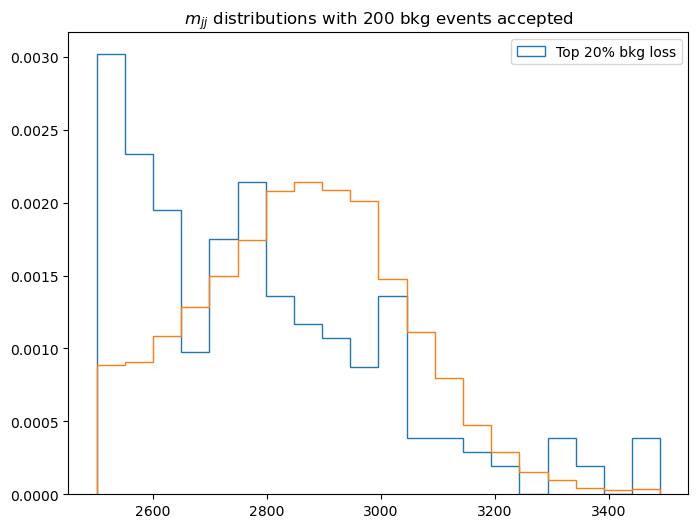

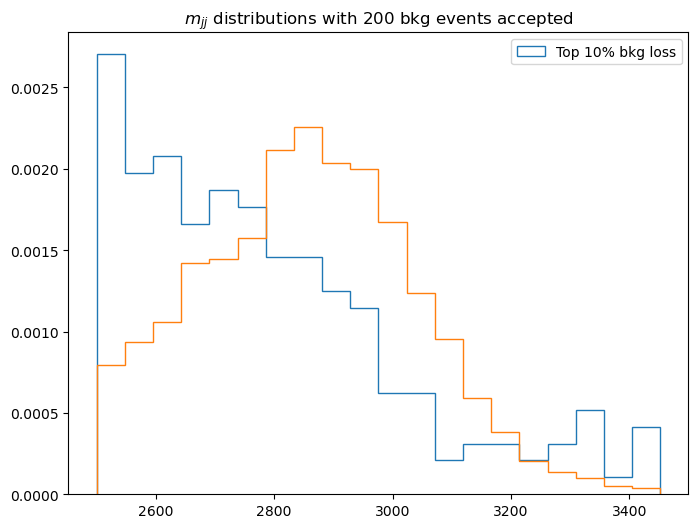

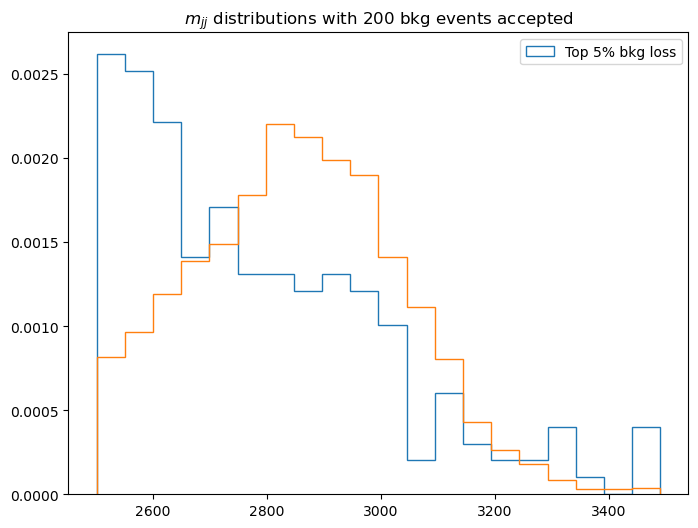

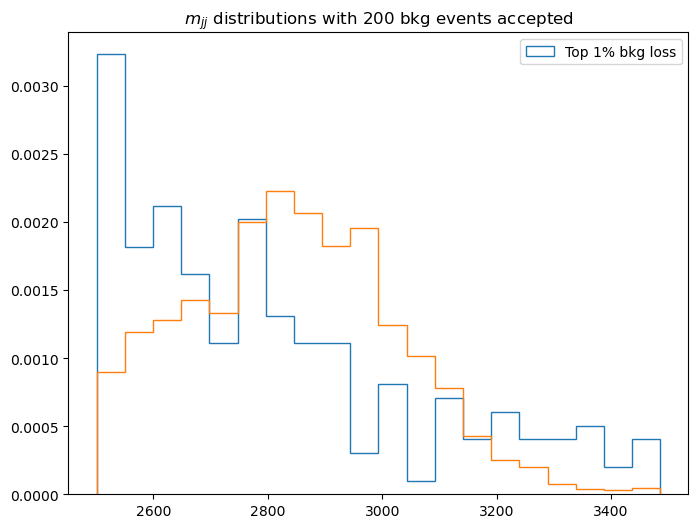

In [63]:
for i,q in enumerate(quantiles):
    plt.figure(figsize=(8,6))
    h1,bins,_ = plt.hist(mass200_bkg[i],bins=20,histtype='step',color=f"C0",density=True,label=f"Top {100*(1-q):.0f}% bkg loss")
    h2 = plt.hist(mass200_sig[i],bins=bins,histtype='step',color=f"C1",density=True)
    plt.title(r"$m_{jj}$ distributions with 200 bkg events accepted")
    plt.legend(loc='upper right')

In [47]:
len(mass200_bkg[3])

203

In [46]:
len(mass200_sig[3])

8692

In [34]:
len(mjj200_bkg)

NameError: name 'mjj200_bkg' is not defined

In [64]:
len(mjj200_sig)

6449

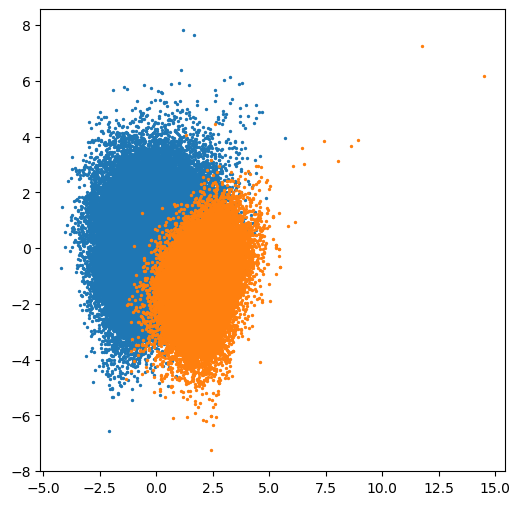

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(lb_bkg,ls_bkg,s=2)
plt.scatter(lb_sig,ls_sig,s=2)